# IBM Telco Customer Churn Analytics
### Exploratory Data Analysis & Business Insights

- **Prepared by:** Hariom Dubey
- **Dataset:** Telco-Customer-Churn-Dataset.csv (IBM Telco Customer Churn dataset)
- **Scope:** Exploratory Data Analysis and business-focused churn diagnostics (no predictive modeling)

---

## 1. Project Overview

This dataset contains account-level records for a telecommunications provider's residential customers. Each row represents one customer and captures their demographic profile, the services they subscribe to (phone, internet, streaming, security add-ons), their contract and billing arrangement, and whether they **churned** — i.e., left the company — during the observation period.

**Customer churn** refers to a customer discontinuing their relationship with the company. In a subscription-based telecom business, churn directly erodes recurring revenue and increases the cost of growth, since replacing a lost customer through acquisition is typically more expensive than retaining an existing one.

**Why churn matters here:** every churned customer represents a loss of recurring monthly revenue and of the acquisition/service investment already made in that relationship. Understanding *which* customers are more likely to churn — and under what conditions — allows a retention team to prioritize outreach, adjust offers, and target interventions where they will have the most impact.

**What this analysis aims to discover:**
- The overall scale of churn in the customer base
- Which customer segments, contract types, services, and billing arrangements are associated with higher or lower churn
- How much monthly recurring revenue is tied to churned customers
- Which combinations of characteristics identify the highest-risk, highest-value segments

**How this supports retention decisions:** the findings and segment tables below are designed to help a retention or customer-success team decide *who* to prioritize for outreach and *what* offer types (e.g., contract upgrade incentives, service bundling, security add-ons) are worth testing — without claiming to prove causation from observational data alone.

This notebook is intended to **complement** an existing Power BI dashboard: rather than reproducing standard dashboard visuals, it goes deeper into segment-level, cross-tabulated, and revenue-exposure analysis that is easier to express in code than in a dashboard.

## 2. Business Problem

The company wants to understand **why customers leave**, identify **customer segments with high churn risk**, understand how **services, contract type, tenure, and charges** relate to churn, and identify **actionable opportunities** to improve retention and reduce revenue loss.

## 3. Business Objectives

1. Measure the overall churn rate and retention rate
2. Understand customer characteristics associated with churn
3. Identify high-churn contract types
4. Analyze churn by tenure
5. Analyze churn across demographic groups (gender, senior citizen, partner, dependents)
6. Analyze churn across telecom services (internet, security, backup, streaming, etc.)
7. Analyze churn across payment methods
8. Investigate the relationship between monthly charges and churn
9. Investigate the relationship between total charges and churn
10. Identify high-risk, high-value customer segments
11. Estimate the monthly recurring revenue exposed to churn
12. Translate findings into actionable retention recommendations

## 4. Dataset Description

- **Source:** IBM Telco Customer Churn sample dataset
- **Granularity:** one row per customer
- **Size:** loaded and confirmed programmatically in Section 7 below
- **Target variable:** `Churn` (Yes / No)

## 5. Tools & Libraries

`pandas`, `numpy` for data handling and computation; `matplotlib`, `seaborn` for visualization. No machine learning or predictive modeling is used — this is a descriptive/diagnostic EDA notebook.


## 6. Import Libraries

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ---- Visualization standards ----
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# Consistent, meaningful color palette used throughout the notebook
COLOR_CHURN = '#D62728'      # red   -> churn / risk
COLOR_RETAIN = '#2CA02C'     # green -> retained / low risk
COLOR_NEUTRAL = '#7F7F7F'    # gray  -> neutral
COLOR_HIGHLIGHT = '#4C72B0'  # blue  -> highlight / general category bars
CHURN_PALETTE = {'Yes': COLOR_CHURN, 'No': COLOR_RETAIN}

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

print('Libraries imported successfully.')


Libraries imported successfully.


## 7. Load Dataset

The uploaded CSV is loaded as-is. No values are modified at this stage — the raw file is preserved in `df`, and all cleaning happens on a copy (`df_clean`) in Section 10, with every step logged.

In [102]:
df = pd.read_csv('Telco-Customer-Churn-Dataset.csv')
print(f"Dataset loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns")


Dataset loaded successfully: 7,043 rows and 21 columns


## 8. Dataset Overview

In [103]:
print("First 5 rows:")
df.head()


First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
print("Last 5 rows:")
df.tail()


Last 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [105]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Shape: 7,043 rows x 21 columns


In [106]:
print("Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:>2}. {col}")


Column names:
 1. customerID
 2. gender
 3. SeniorCitizen
 4. Partner
 5. Dependents
 6. tenure
 7. PhoneService
 8. MultipleLines
 9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [107]:
print("Data types:")
df.dtypes


Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [108]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [109]:
print("Statistical summary - numerical columns:")
df.describe()


Statistical summary - numerical columns:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [110]:
print("Statistical summary - categorical columns:")
df.describe(include='object')


Statistical summary - categorical columns:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [111]:
print("Number of unique values per column:")
df.nunique().sort_values(ascending=False)


Number of unique values per column:


customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
gender                 2
PhoneService           2
PaperlessBilling       2
Dependents             2
Partner                2
SeniorCitizen          2
Churn                  2
dtype: int64

## 9. Data Dictionary

Descriptions reflect the actual meaning of each field as used in this dataset (standard IBM Telco Churn schema).

In [112]:
data_dictionary = pd.DataFrame([
    ['customerID', 'String', 'Unique identifier for each customer', 'Primary key; used to detect duplicates, not for analysis'],
    ['gender', 'Categorical', 'Customer gender (Male/Female)', 'Demographic profile'],
    ['SeniorCitizen', 'Binary (0/1)', 'Whether the customer is a senior citizen', 'Demographic profile / age-related segment'],
    ['Partner', 'Categorical (Yes/No)', 'Whether the customer has a partner', 'Household composition'],
    ['Dependents', 'Categorical (Yes/No)', 'Whether the customer has dependents', 'Household composition'],
    ['tenure', 'Numeric (months)', 'Number of months the customer has stayed with the company', 'Customer lifecycle stage / loyalty indicator'],
    ['PhoneService', 'Categorical (Yes/No)', 'Whether the customer subscribes to phone service', 'Core service subscription'],
    ['MultipleLines', 'Categorical', 'Whether the customer has multiple phone lines', 'Service usage intensity'],
    ['InternetService', 'Categorical', 'Type of internet service (DSL / Fiber optic / No)', 'Core service subscription and service tier'],
    ['OnlineSecurity', 'Categorical', 'Whether the customer has online security add-on', 'Value-added service subscription'],
    ['OnlineBackup', 'Categorical', 'Whether the customer has online backup add-on', 'Value-added service subscription'],
    ['DeviceProtection', 'Categorical', 'Whether the customer has device protection add-on', 'Value-added service subscription'],
    ['TechSupport', 'Categorical', 'Whether the customer has tech support add-on', 'Value-added service subscription'],
    ['StreamingTV', 'Categorical', 'Whether the customer has streaming TV add-on', 'Value-added service subscription'],
    ['StreamingMovies', 'Categorical', 'Whether the customer has streaming movies add-on', 'Value-added service subscription'],
    ['Contract', 'Categorical', 'Contract term (Month-to-month / One year / Two year)', 'Commitment level; strongly tied to switching cost'],
    ['PaperlessBilling', 'Categorical (Yes/No)', 'Whether the customer uses paperless billing', 'Billing preference / digital engagement proxy'],
    ['PaymentMethod', 'Categorical', 'How the customer pays their bill', 'Billing/payment friction proxy'],
    ['MonthlyCharges', 'Numeric (currency)', "Customer's current monthly charge", 'Recurring revenue per customer; price-sensitivity proxy'],
    ['TotalCharges', 'Numeric (currency, stored as text in raw file)', 'Total amount charged to the customer to date', 'Cumulative revenue / lifetime value proxy'],
    ['Churn', 'Categorical (Yes/No)', 'Whether the customer left the company', 'Target variable for this analysis'],
], columns=['Column Name', 'Data Type', 'Description', 'Business Meaning'])

data_dictionary


,Column Name,Data Type,Description,Business Meaning
0,customerID,String,Unique identifier for each customer,"Primary key; used to detect duplicates, not fo..."
1,gender,Categorical,Customer gender (Male/Female),Demographic profile
2,SeniorCitizen,Binary (0/1),Whether the customer is a senior citizen,Demographic profile / age-related segment
3,Partner,Categorical (Yes/No),Whether the customer has a partner,Household composition
4,Dependents,Categorical (Yes/No),Whether the customer has dependents,Household composition
5,tenure,Numeric (months),Number of months the customer has stayed with ...,Customer lifecycle stage / loyalty indicator
6,PhoneService,Categorical (Yes/No),Whether the customer subscribes to phone service,Core service subscription
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,Service usage intensity
8,InternetService,Categorical,Type of internet service (DSL / Fiber optic / No),Core service subscription and service tier
9,OnlineSecurity,Categorical,Whether the customer has online security add-on,Value-added service subscription


## 10. Data Quality Assessment

A full audit is performed before any cleaning so that every treatment applied later is justified by an observed issue, not assumed.

In [113]:
# A. Missing values (as recognized by pandas on load)
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

# E/H. Unique value counts, dtype
quality_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct,
    'Data Type': df.dtypes.astype(str),
    'Unique Values': df.nunique()
})
quality_summary


,Missing Count,Missing %,Data Type,Unique Values
customerID,0,0.0,object,7043
gender,0,0.0,object,2
SeniorCitizen,0,0.0,int64,2
Partner,0,0.0,object,2
Dependents,0,0.0,object,2
tenure,0,0.0,int64,73
PhoneService,0,0.0,object,2
MultipleLines,0,0.0,object,3
InternetService,0,0.0,object,3
OnlineSecurity,0,0.0,object,3


In [114]:
# B. Duplicate rows (full row duplicates)
full_duplicates = df.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

# C. Duplicate customer IDs
duplicate_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customerID values: {duplicate_ids}")


Fully duplicated rows: 0
Duplicate customerID values: 0


In [115]:
# D/G. TotalCharges is stored as text (object dtype) rather than numeric.
# Inspect non-numeric / blank entries before converting.
non_numeric_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(f"Rows where TotalCharges cannot be parsed as numeric: {non_numeric_mask.sum()}")

problem_rows = df.loc[non_numeric_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
problem_rows


Rows where TotalCharges cannot be parsed as numeric: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [116]:
# Check whether the unparsable TotalCharges values share a common characteristic (e.g. new customers)
print("Tenure distribution for rows with unparsable TotalCharges:")
print(df.loc[non_numeric_mask, 'tenure'].describe())


Tenure distribution for rows with unparsable TotalCharges:
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


In [117]:
# F. Check categorical columns for unexpected / invalid category values
categorical_cols = df.select_dtypes(include='object').columns.drop('customerID')
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")


gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
TotalCharges: [' ', '100.2', '100.25', '100.35', '100.4', '100.8', '100.9', '1001.2', '1001.5', '1003.05', '1004.35', '1004.5', '1004.75', '1005.7', '1006.9', '1007.8', '1007.9', '1008.55', '1008.7', '1009.25', '101.1', '101.45', '101.65', '101.9', '1010', '1011.05', '1011.5', '1011.8', '1012.4

In [118]:
# G. Blank strings (whitespace-only) hiding in object columns
for col in df.select_dtypes(include='object').columns:
    blank_count = (df[col].astype(str).str.strip() == '').sum()
    if blank_count > 0:
        print(f"{col}: {blank_count} blank/whitespace-only entries")


TotalCharges: 11 blank/whitespace-only entries


In [119]:
# I. Numerical range checks for plausibility
print("tenure range:", df['tenure'].min(), '-', df['tenure'].max(), 'months')
print("MonthlyCharges range:", df['MonthlyCharges'].min(), '-', df['MonthlyCharges'].max())
print("SeniorCitizen unique values:", sorted(df['SeniorCitizen'].unique()))


tenure range: 0 - 72 months
MonthlyCharges range: 18.25 - 118.75
SeniorCitizen unique values: [np.int64(0), np.int64(1)]


**Data Quality Findings Summary**

- No fully duplicated rows and no duplicate `customerID` values were found — each row represents a unique customer.
- `TotalCharges` is stored as text and contains a small number of entries that cannot be parsed as numeric (blank/whitespace strings). These rows all correspond to customers with `tenure = 0`, i.e., brand-new customers who have not yet been billed a total amount — a logically consistent explanation rather than a random data error.
- No invalid/unexpected category labels were found in the categorical columns.
- `tenure` and `MonthlyCharges` fall within plausible numeric ranges with no negative or impossible values.
- `SeniorCitizen` is encoded as 0/1 rather than Yes/No, unlike the other binary Yes/No fields — this is addressed in feature engineering (Section 11).

## 11. Data Cleaning & Preprocessing

The original `df` is preserved unmodified. All cleaning is performed on a working copy, `df_clean`, with each step explained.

In [120]:
df_clean = df.copy()
print(f"Working copy created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Working copy created: 7,043 rows x 21 columns


In [121]:
# --- Cleaning Step 1: Convert TotalCharges to numeric ---
# Problem: TotalCharges is stored as text and contains blank entries that fail numeric parsing.
# Action: convert to numeric with errors='coerce', turning unparsable blanks into NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

rows_now_nan = df_clean['TotalCharges'].isna().sum()
print(f"TotalCharges converted to numeric. Resulting NaN count: {rows_now_nan}")


TotalCharges converted to numeric. Resulting NaN count: 11


In [122]:
# --- Cleaning Step 2: Handle the resulting missing TotalCharges values ---
# Problem: the NaNs correspond to customers with tenure = 0 (i.e., TotalCharges is legitimately
# undefined/zero for a customer who has not completed a billing cycle yet), not a random data error.
# Action: impute these specific rows with 0, since a customer with zero tenure has been charged
# a cumulative total of 0 to date. We do NOT drop these rows, since they are valid customer records
# and dropping them would bias tenure-0 / new-customer analysis.
mask_zero_tenure_nan = df_clean['TotalCharges'].isna() & (df_clean['tenure'] == 0)
print(f"Rows confirmed as tenure=0 with missing TotalCharges: {mask_zero_tenure_nan.sum()}")

df_clean.loc[mask_zero_tenure_nan, 'TotalCharges'] = 0.0

remaining_nan = df_clean['TotalCharges'].isna().sum()
print(f"Remaining missing TotalCharges after imputation: {remaining_nan}")


Rows confirmed as tenure=0 with missing TotalCharges: 11
Remaining missing TotalCharges after imputation: 0


In [123]:
# --- Cleaning Step 3: Duplicate check (confirm, do not blindly remove) ---
# Problem: none observed (checked in Data Quality Assessment).
# Action: re-verify on the cleaned frame before proceeding.
print(f"Duplicate rows in df_clean: {df_clean.duplicated().sum()}")
print(f"Duplicate customerID in df_clean: {df_clean['customerID'].duplicated().sum()}")


Duplicate rows in df_clean: 0
Duplicate customerID in df_clean: 0


In [124]:
# --- Cleaning Step 4: Standardize SeniorCitizen encoding for readability ---
# Problem: SeniorCitizen is 0/1 while every other Yes/No demographic field uses text labels,
# which is inconsistent and less readable in grouped outputs and chart legends.
# Action: add a labeled column while KEEPING the original numeric column intact for reference.
df_clean['SeniorCitizenLabel'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df_clean[['SeniorCitizen', 'SeniorCitizenLabel']].drop_duplicates())


    SeniorCitizen SeniorCitizenLabel
0               0                 No
20              1                Yes


In [125]:
# --- Cleaning Step 5: Data type confirmation ---
print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)


tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


In [126]:
cleaning_log = pd.DataFrame([
    ['TotalCharges text-to-numeric', 'Stored as text; blank values fail numeric parsing',
     "Converted with pd.to_numeric(errors='coerce')", 'Enables numeric analysis',
     f"{rows_now_nan} rows became NaN"],
    ['TotalCharges missing value handling', 'NaNs correspond to customers with tenure = 0',
     'Imputed these rows with 0.0 (no rows dropped)', 'Zero tenure customers have not been billed a cumulative total yet',
     f"{remaining_nan} rows remain missing"],
    ['Duplicate check', 'Verify no duplicate rows/IDs before analysis', 'Checked df.duplicated() and customerID.duplicated()',
     'Confirms one row = one customer', '0 duplicates found'],
    ['SeniorCitizen labeling', '0/1 encoding inconsistent with other Yes/No fields', 'Added SeniorCitizenLabel (No/Yes), original column retained',
     'Improves readability in charts/tables without losing original data', 'New column added, no data lost'],
], columns=['Step', 'Problem', 'Action Taken', 'Reason', 'Result'])

cleaning_log


,Step,Problem,Action Taken,Reason,Result
0,TotalCharges text-to-numeric,Stored as text; blank values fail numeric parsing,Converted with pd.to_numeric(errors='coerce'),Enables numeric analysis,11 rows became NaN
1,TotalCharges missing value handling,NaNs correspond to customers with tenure = 0,Imputed these rows with 0.0 (no rows dropped),Zero tenure customers have not been billed a c...,0 rows remain missing
2,Duplicate check,Verify no duplicate rows/IDs before analysis,Checked df.duplicated() and customerID.duplica...,Confirms one row = one customer,0 duplicates found
3,SeniorCitizen labeling,0/1 encoding inconsistent with other Yes/No fi...,"Added SeniorCitizenLabel (No/Yes), original co...",Improves readability in charts/tables without ...,"New column added, no data lost"


## 12. Feature Engineering

Only variables that directly support the churn analysis below are created.

In [127]:
# 1. ChurnFlag - numeric encoding of the target variable, needed for correlation/rate calculations
df_clean['ChurnFlag'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

# 2. TenureGroup - bucketed tenure so churn patterns across customer lifecycle stages are easier to read
tenure_bins = [-1, 12, 24, 36, 48, 60, np.inf]
tenure_labels = ['0-12 Months', '13-24 Months', '25-36 Months', '37-48 Months', '49-60 Months', '60+ Months']
df_clean['TenureGroup'] = pd.cut(df_clean['tenure'], bins=tenure_bins, labels=tenure_labels)

# 3. SeniorCitizenLabel already created in cleaning step 4.

# 4. MonthlyChargeGroup - bands based on the actual quartiles of MonthlyCharges in this dataset,
# rather than arbitrary round-number cutoffs, so each band reflects a real, comparable slice of customers.
q1, q2, q3 = df_clean['MonthlyCharges'].quantile([0.25, 0.5, 0.75])
print(f"MonthlyCharges quartiles -> Q1: {q1:.2f}, Median: {q2:.2f}, Q3: {q3:.2f}")

def charge_band(x):
    if x <= q1:
        return f'Low (<= {q1:.0f})'
    elif x <= q2:
        return f'Medium ({q1:.0f}-{q2:.0f})'
    elif x <= q3:
        return f'High ({q2:.0f}-{q3:.0f})'
    else:
        return f'Very High (> {q3:.0f})'

df_clean['MonthlyChargeGroup'] = df_clean['MonthlyCharges'].apply(charge_band)

df_clean[['tenure', 'TenureGroup', 'MonthlyCharges', 'MonthlyChargeGroup', 'ChurnFlag']].head()


MonthlyCharges quartiles -> Q1: 35.50, Median: 70.35, Q3: 89.85


,tenure,TenureGroup,MonthlyCharges,MonthlyChargeGroup,ChurnFlag
0,1,0-12 Months,29.85,Low (<= 36),0
1,34,25-36 Months,56.95,Medium (36-70),0
2,2,0-12 Months,53.85,Medium (36-70),1
3,45,37-48 Months,42.30,Medium (36-70),0
4,2,0-12 Months,70.70,High (70-90),1


In [128]:
print("TenureGroup distribution:")
print(df_clean['TenureGroup'].value_counts().sort_index())
print()
print("MonthlyChargeGroup distribution:")
print(df_clean['MonthlyChargeGroup'].value_counts())


TenureGroup distribution:
TenureGroup
0-12 Months     2186
13-24 Months    1024
25-36 Months     832
37-48 Months     762
49-60 Months     832
60+ Months      1407
Name: count, dtype: int64

MonthlyChargeGroup distribution:
MonthlyChargeGroup
Medium (36-70)      1766
Low (<= 36)         1762
Very High (> 90)    1758
High (70-90)        1757
Name: count, dtype: int64


## 13. Key Business KPIs

All figures below are computed directly from `df_clean`.

In [129]:
total_customers = len(df_clean)
churned_customers = (df_clean['Churn'] == 'Yes').sum()
retained_customers = (df_clean['Churn'] == 'No').sum()
churn_rate = churned_customers / total_customers * 100
retention_rate = retained_customers / total_customers * 100

avg_tenure = df_clean['tenure'].mean()
avg_monthly_charges = df_clean['MonthlyCharges'].mean()
avg_total_charges = df_clean['TotalCharges'].mean()

monthly_charges_churned_sum = df_clean.loc[df_clean['Churn'] == 'Yes', 'MonthlyCharges'].sum()
avg_monthly_charges_churned = df_clean.loc[df_clean['Churn'] == 'Yes', 'MonthlyCharges'].mean()
avg_monthly_charges_retained = df_clean.loc[df_clean['Churn'] == 'No', 'MonthlyCharges'].mean()
avg_tenure_churned = df_clean.loc[df_clean['Churn'] == 'Yes', 'tenure'].mean()
avg_tenure_retained = df_clean.loc[df_clean['Churn'] == 'No', 'tenure'].mean()

kpi_table = pd.DataFrame([
    ['Total Customers', f"{total_customers:,}"],
    ['Churned Customers', f"{churned_customers:,}"],
    ['Retained Customers', f"{retained_customers:,}"],
    ['Overall Churn Rate', f"{churn_rate:.2f}%"],
    ['Retention Rate', f"{retention_rate:.2f}%"],
    ['Average Tenure (all customers)', f"{avg_tenure:.1f} months"],
    ['Average Monthly Charges (all customers)', f"${avg_monthly_charges:.2f}"],
    ['Average Total Charges (all customers)', f"${avg_total_charges:,.2f}"],
    ['Monthly Charges Sum - Churned Customers', f"${monthly_charges_churned_sum:,.2f}"],
    ['Average Monthly Charges - Churned Customers', f"${avg_monthly_charges_churned:.2f}"],
    ['Average Monthly Charges - Retained Customers', f"${avg_monthly_charges_retained:.2f}"],
    ['Average Tenure - Churned Customers', f"{avg_tenure_churned:.1f} months"],
    ['Average Tenure - Retained Customers', f"{avg_tenure_retained:.1f} months"],
], columns=['KPI', 'Value'])

kpi_table


,KPI,Value
0,Total Customers,"7,043"
1,Churned Customers,"1,869"
2,Retained Customers,"5,174"
3,Overall Churn Rate,26.54%
4,Retention Rate,73.46%
5,Average Tenure (all customers),32.4 months
6,Average Monthly Charges (all customers),$64.76
7,Average Total Charges (all customers),"$2,279.73"
8,Monthly Charges Sum - Churned Customers,"$139,130.85"
9,Average Monthly Charges - Churned Customers,$74.44


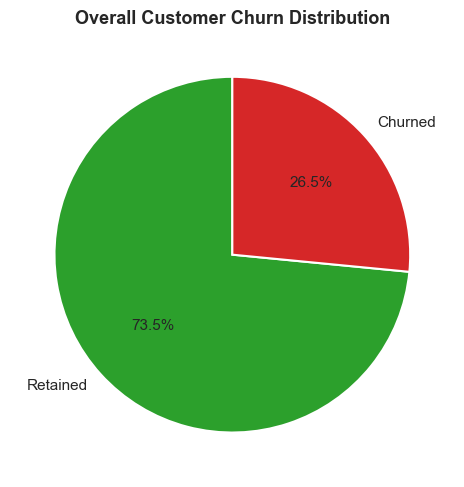

In [130]:
fig, ax = plt.subplots(figsize=(5, 5))
counts = df_clean['Churn'].value_counts().reindex(['No', 'Yes'])
colors = [COLOR_RETAIN, COLOR_CHURN]
wedges, texts, autotexts = ax.pie(
    counts, labels=['Retained', 'Churned'], colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Overall Customer Churn Distribution')
plt.tight_layout()
plt.show()


**Business Interpretation:** This single chart establishes the baseline churn rate for the entire customer base and is the reference point against which every segment-level churn rate in this notebook should be compared. A segment whose churn rate sits well above the overall rate is where retention effort is likely to be most impactful.

## 14. Exploratory Data Analysis

A reusable function computes churn rate by category for any categorical column, keeping the analysis consistent and avoiding repeated code.

In [131]:
def churn_summary_by_category(data, column, min_group_size=30):
    """Return customer count, churned count, churn rate, and churn share for each category of `column`.
    Flags groups smaller than min_group_size so small-sample results aren't over-interpreted.
    """
    grouped = data.groupby(column, observed=True).agg(
        Customers=('Churn', 'size'),
        Churned=('ChurnFlag', 'sum')
    )
    grouped['Churn Rate (%)'] = (grouped['Churned'] / grouped['Customers'] * 100).round(2)
    grouped['Churn Share (%)'] = (grouped['Churned'] / grouped['Churned'].sum() * 100).round(2)
    grouped['Small Sample Warning'] = grouped['Customers'] < min_group_size
    return grouped.sort_values('Churn Rate (%)', ascending=False)


def plot_churn_rate_by_category(data, column, title, ax=None, min_group_size=30):
    """Horizontal bar chart of churn rate by category, sorted descending, with overall churn rate reference line."""
    summary = churn_summary_by_category(data, column, min_group_size)
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(7, max(2.5, 0.5 * len(summary))))
    bars = ax.barh(summary.index.astype(str), summary['Churn Rate (%)'], color=COLOR_HIGHLIGHT)
    overall_rate = data['ChurnFlag'].mean() * 100
    ax.axvline(overall_rate, color=COLOR_CHURN, linestyle='--', linewidth=1.3,
               label=f'Overall churn rate ({overall_rate:.1f}%)')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis()
    for bar, (idx, row) in zip(bars, summary.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{row['Churn Rate (%)']:.1f}% (n={int(row['Customers'])})",
                va='center', fontsize=8.5)
    ax.set_xlim(0, max(summary['Churn Rate (%)'].max() + 12, overall_rate + 10))
    if own_ax:
        plt.tight_layout()
        plt.show()
    return summary

print("Reusable churn analysis functions defined.")


Reusable churn analysis functions defined.


### A. Overall Churn Distribution

Already shown in Section 13 above (KPI pie chart) — included there to anchor all KPIs together.

### B-E. Demographics: Gender, Senior Citizen, Partner, Dependents

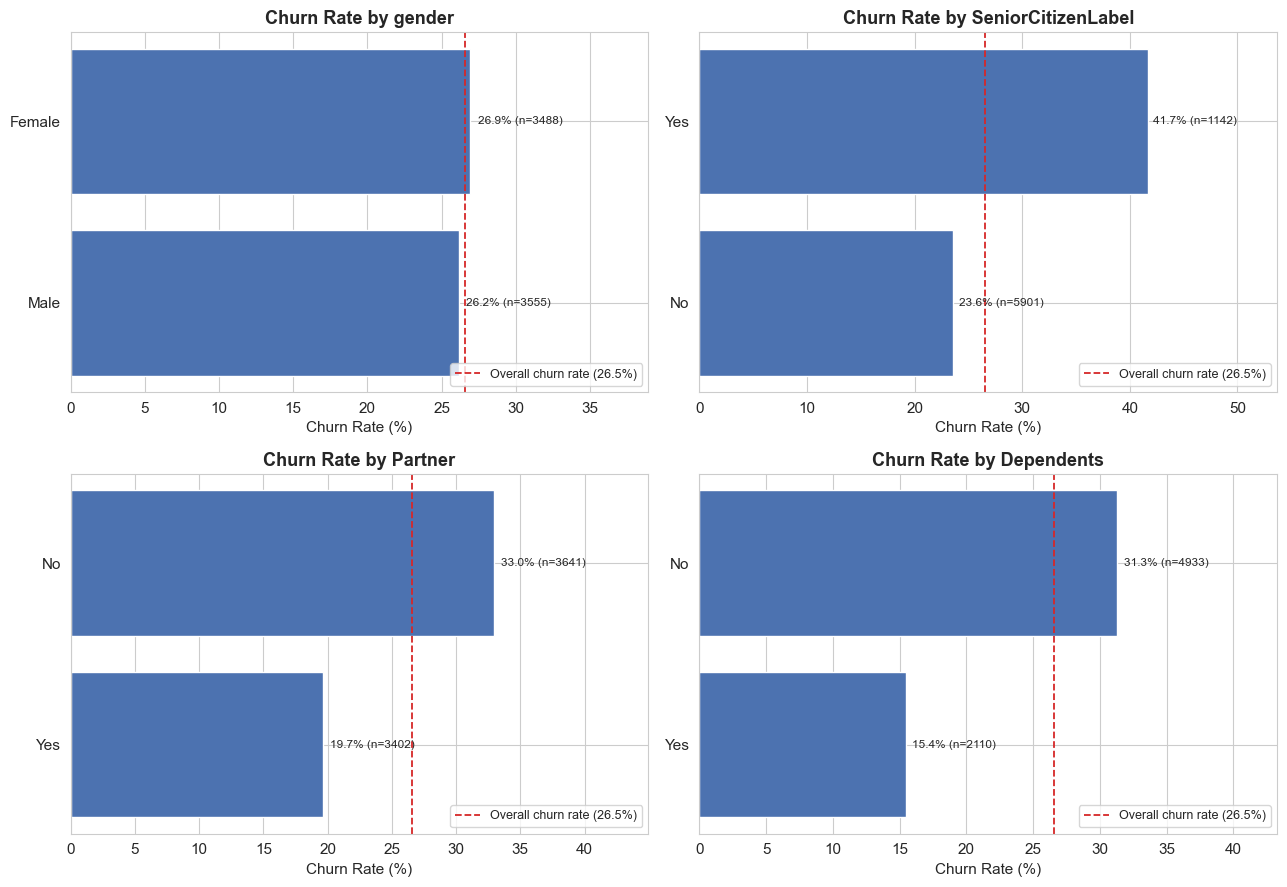

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
demo_summaries = {}
for ax, col in zip(axes.flatten(), ['gender', 'SeniorCitizenLabel', 'Partner', 'Dependents']):
    demo_summaries[col] = plot_churn_rate_by_category(df_clean, col, f'Churn Rate by {col}', ax=ax)
plt.tight_layout()
plt.show()


In [133]:
for col, summary in demo_summaries.items():
    print(f"--- {col} ---")
    print(summary[['Customers', 'Churned', 'Churn Rate (%)']])
    print()


--- gender ---
        Customers  Churned  Churn Rate (%)
gender                                    
Female       3488      939           26.92
Male         3555      930           26.16

--- SeniorCitizenLabel ---
                    Customers  Churned  Churn Rate (%)
SeniorCitizenLabel                                    
Yes                      1142      476           41.68
No                       5901     1393           23.61

--- Partner ---
         Customers  Churned  Churn Rate (%)
Partner                                    
No            3641     1200           32.96
Yes           3402      669           19.66

--- Dependents ---
            Customers  Churned  Churn Rate (%)
Dependents                                    
No               4933     1543           31.28
Yes              2110      326           15.45



### F. Tenure Group

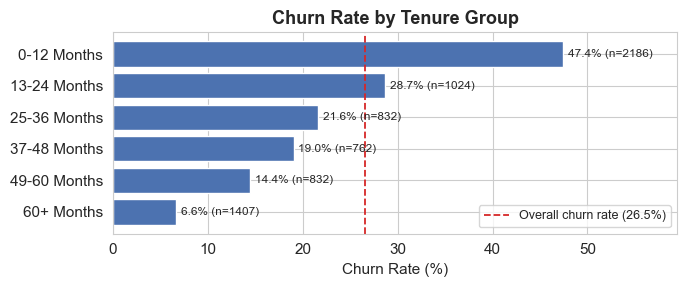

,Customers,Churned,Churn Rate (%),Churn Share (%),Small Sample Warning
TenureGroup,,,,,
0-12 Months,2186,1037,47.44,55.48,False
13-24 Months,1024,294,28.71,15.73,False
25-36 Months,832,180,21.63,9.63,False
37-48 Months,762,145,19.03,7.76,False
49-60 Months,832,120,14.42,6.42,False
60+ Months,1407,93,6.61,4.98,False


In [134]:
tenure_group_summary = plot_churn_rate_by_category(
    df_clean.assign(TenureGroup=df_clean['TenureGroup'].astype(str)),
    'TenureGroup', 'Churn Rate by Tenure Group'
)
tenure_group_summary


### G-H. Phone Service & Multiple Lines

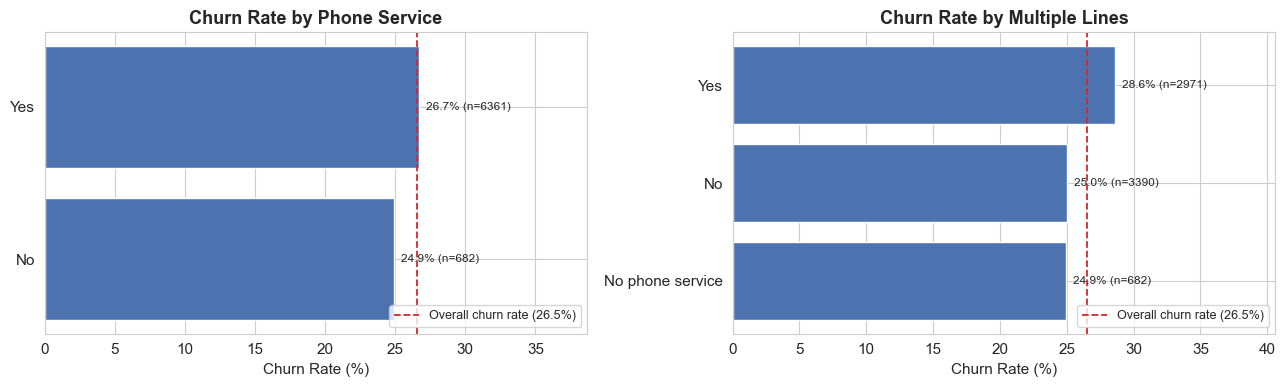

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
phone_summary = plot_churn_rate_by_category(df_clean, 'PhoneService', 'Churn Rate by Phone Service', ax=axes[0])
lines_summary = plot_churn_rate_by_category(df_clean, 'MultipleLines', 'Churn Rate by Multiple Lines', ax=axes[1])
plt.tight_layout()
plt.show()


### I. Internet Service

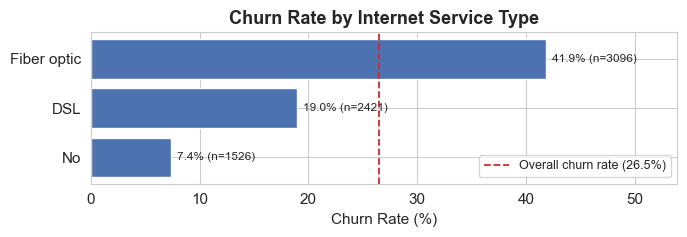

,Customers,Churned,Churn Rate (%),Churn Share (%),Small Sample Warning
InternetService,,,,,
Fiber optic,3096,1297,41.89,69.40,False
DSL,2421,459,18.96,24.56,False
No,1526,113,7.40,6.05,False


In [136]:
internet_summary = plot_churn_rate_by_category(df_clean, 'InternetService', 'Churn Rate by Internet Service Type')
internet_summary


### J-M. Add-on Services: Online Security, Online Backup, Device Protection, Tech Support

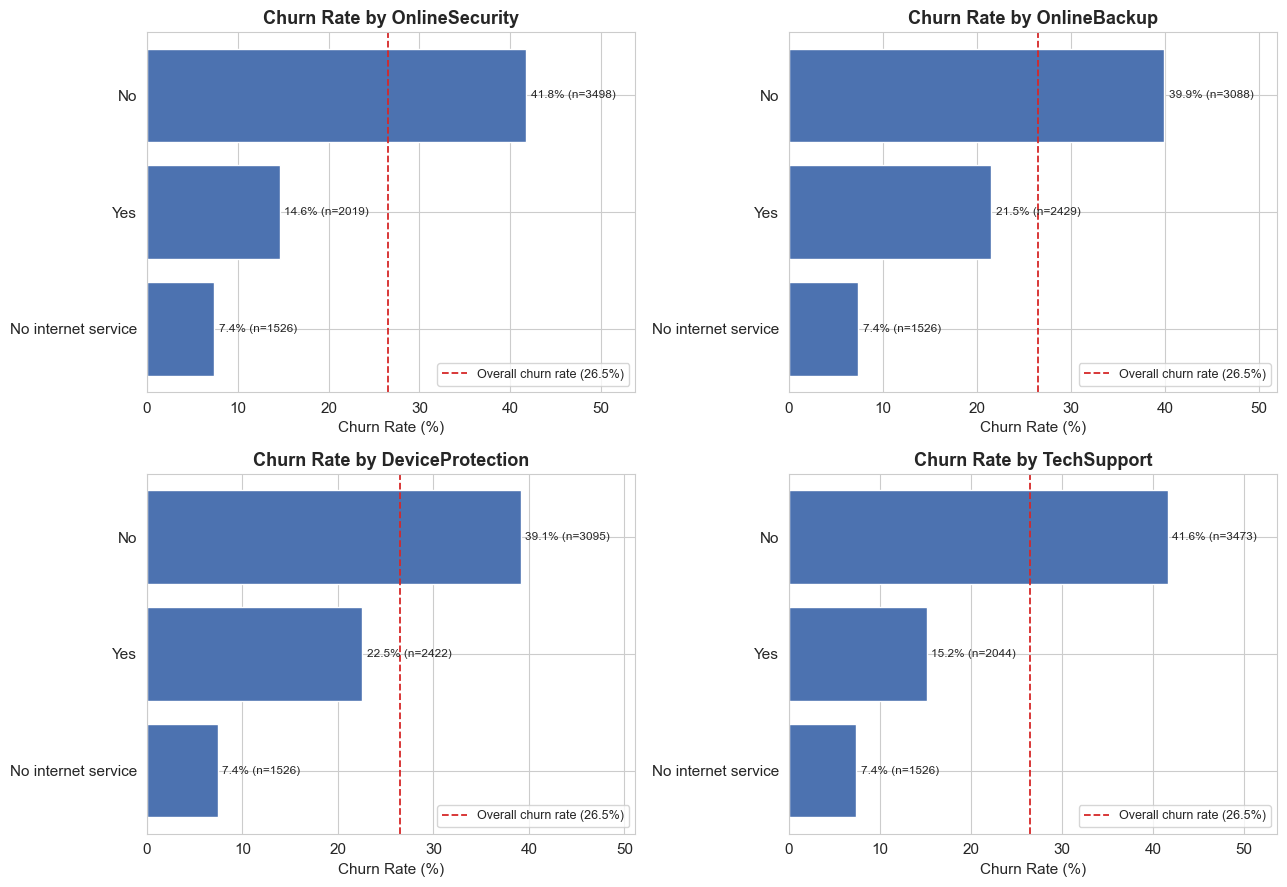

In [137]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
addon_summaries = {}
for ax, col in zip(axes.flatten(), ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']):
    addon_summaries[col] = plot_churn_rate_by_category(df_clean, col, f'Churn Rate by {col}', ax=ax)
plt.tight_layout()
plt.show()


### N-O. Streaming Services: Streaming TV, Streaming Movies

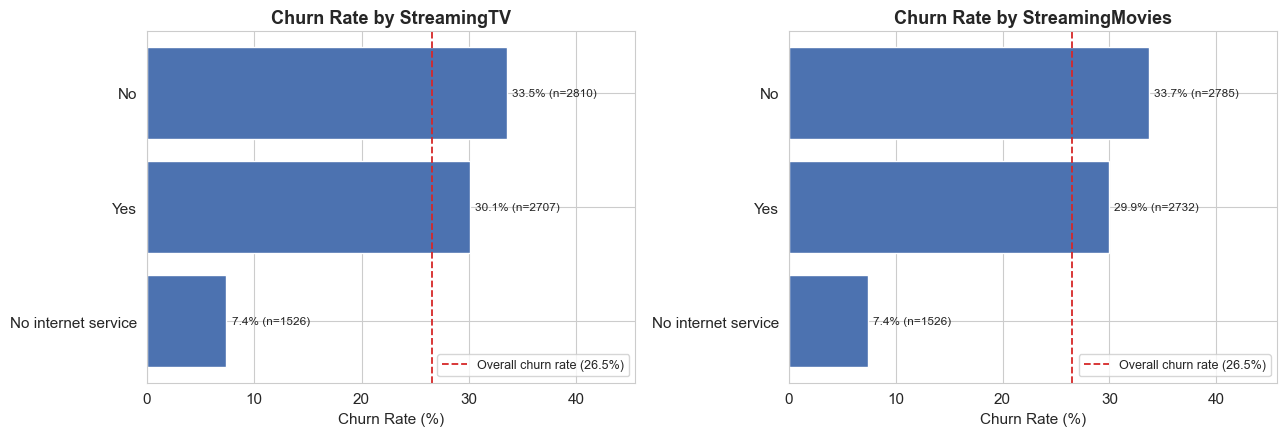

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
streaming_summaries = {}
for ax, col in zip(axes, ['StreamingTV', 'StreamingMovies']):
    streaming_summaries[col] = plot_churn_rate_by_category(df_clean, col, f'Churn Rate by {col}', ax=ax)
plt.tight_layout()
plt.show()


### P. Contract

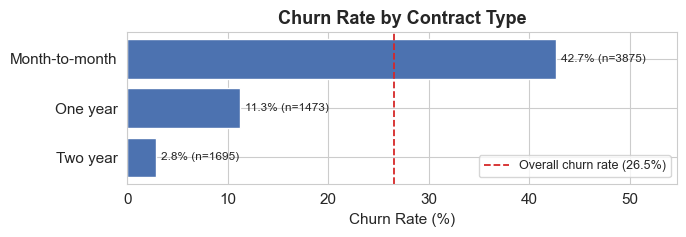

,Customers,Churned,Churn Rate (%),Churn Share (%),Small Sample Warning
Contract,,,,,
Month-to-month,3875,1655,42.71,88.55,False
One year,1473,166,11.27,8.88,False
Two year,1695,48,2.83,2.57,False


In [139]:
contract_summary = plot_churn_rate_by_category(df_clean, 'Contract', 'Churn Rate by Contract Type')
contract_summary


### Q-R. Paperless Billing & Payment Method

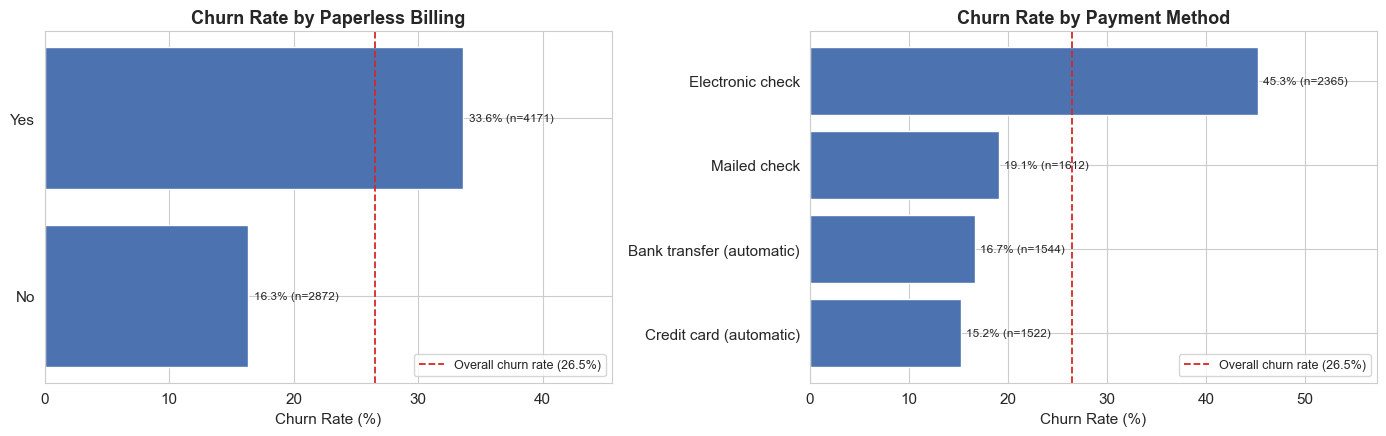

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
paperless_summary = plot_churn_rate_by_category(df_clean, 'PaperlessBilling', 'Churn Rate by Paperless Billing', ax=axes[0])
payment_summary = plot_churn_rate_by_category(df_clean, 'PaymentMethod', 'Churn Rate by Payment Method', ax=axes[1])
plt.tight_layout()
plt.show()


**Business Interpretation (Section 14 overview):** Across the categorical sweep above, churn is clearly not evenly distributed. Segments whose bars extend well past the dashed overall-churn-rate line warrant closer attention in the driver and segmentation analysis that follows — these single-variable views are a starting point, not a final diagnosis, since several of these factors are correlated with each other (e.g., contract type and tenure).

## 15. Tenure Analysis

Examining whether early-tenure customers appear more vulnerable to churn.

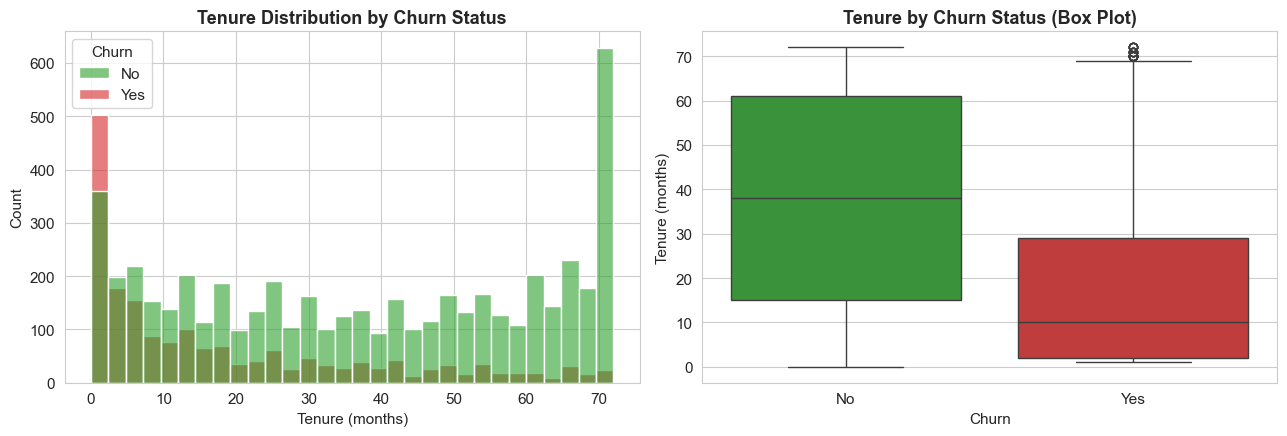

Average tenure - churned customers: 18.0 months
Average tenure - retained customers: 37.6 months
Median tenure - churned customers: 10.0 months
Median tenure - retained customers: 38.0 months


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution of tenure split by churn status
sns.histplot(data=df_clean, x='tenure', hue='Churn', hue_order=['No', 'Yes'], palette=CHURN_PALETTE,
             bins=30, multiple='layer', alpha=0.6, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')

sns.boxplot(data=df_clean, x='Churn', y='tenure', order=['No', 'Yes'], palette=CHURN_PALETTE, ax=axes[1])
axes[1].set_title('Tenure by Churn Status (Box Plot)')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

print(f"Average tenure - churned customers: {avg_tenure_churned:.1f} months")
print(f"Average tenure - retained customers: {avg_tenure_retained:.1f} months")
print(f"Median tenure - churned customers: {df_clean.loc[df_clean.Churn=='Yes','tenure'].median():.1f} months")
print(f"Median tenure - retained customers: {df_clean.loc[df_clean.Churn=='No','tenure'].median():.1f} months")


**Business Interpretation:** Churned customers show a markedly lower average and median tenure than retained customers, and the tenure-group churn-rate chart in Section 14F shows the highest churn concentrated in the earliest tenure bracket, declining as tenure increases. This pattern is **associated with** — not proven to **cause** — churn; it is consistent with new customers still evaluating the service and being more willing to switch providers, but confirming a causal mechanism would require a controlled study.

## 16. Contract Analysis

In [142]:
contract_stats = df_clean.groupby('Contract', observed=True).agg(
    Customers=('Churn', 'size'),
    Churned=('ChurnFlag', 'sum'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean')
)
contract_stats['Churn Rate (%)'] = (contract_stats['Churned'] / contract_stats['Customers'] * 100).round(2)
contract_stats = contract_stats.sort_values('Churn Rate (%)', ascending=False)
contract_stats[['Customers', 'Churned', 'Churn Rate (%)', 'Avg_Monthly_Charges', 'Avg_Tenure']].round(2)


,Customers,Churned,Churn Rate (%),Avg_Monthly_Charges,Avg_Tenure
Contract,,,,,
Month-to-month,3875,1655,42.71,66.40,18.04
One year,1473,166,11.27,65.05,42.04
Two year,1695,48,2.83,60.77,56.74


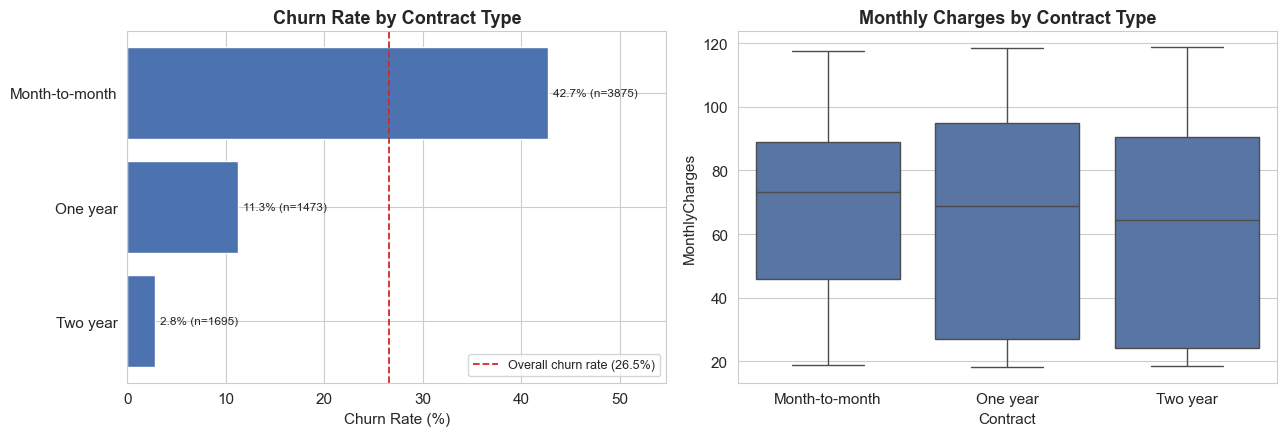

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_churn_rate_by_category(df_clean, 'Contract', 'Churn Rate by Contract Type', ax=axes[0])
sns.boxplot(data=df_clean, x='Contract', y='MonthlyCharges',
            order=contract_stats.index, ax=axes[1], color=COLOR_HIGHLIGHT)
axes[1].set_title('Monthly Charges by Contract Type')
plt.tight_layout()
plt.show()


**Business Interpretation:** The contract-type comparison above identifies which contract carries the highest churn rate (see the table's top row, sorted descending). Month-to-month arrangements carry no penalty for leaving, so — consistent with the tenure findings — a lower switching cost is a plausible contributing factor, though this analysis cannot isolate contract type from the fact that month-to-month customers also tend to have shorter tenure. Longer-term contracts are associated with materially lower churn, which is useful context for contract-upgrade retention offers explored later in this notebook.

## 17. Service Analysis

Consolidated view across internet and add-on services to identify which service categories show unusually high or low churn.

In [144]:
service_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

service_rows = []
for col in service_cols:
    summary = churn_summary_by_category(df_clean, col)
    for category, row in summary.iterrows():
        service_rows.append({
            'Service': col, 'Category': category, 'Customers': int(row['Customers']),
            'Churned': int(row['Churned']), 'Churn Rate (%)': row['Churn Rate (%)']
        })

service_overview = pd.DataFrame(service_rows).sort_values('Churn Rate (%)', ascending=False)
service_overview.reset_index(drop=True, inplace=True)
service_overview.head(15)


,Service,Category,Customers,Churned,Churn Rate (%)
0,InternetService,Fiber optic,3096,1297,41.89
1,OnlineSecurity,No,3498,1461,41.77
2,TechSupport,No,3473,1446,41.64
3,OnlineBackup,No,3088,1233,39.93
4,DeviceProtection,No,3095,1211,39.13
5,StreamingMovies,No,2785,938,33.68
6,StreamingTV,No,2810,942,33.52
7,StreamingTV,Yes,2707,814,30.07
8,StreamingMovies,Yes,2732,818,29.94
9,MultipleLines,Yes,2971,850,28.61


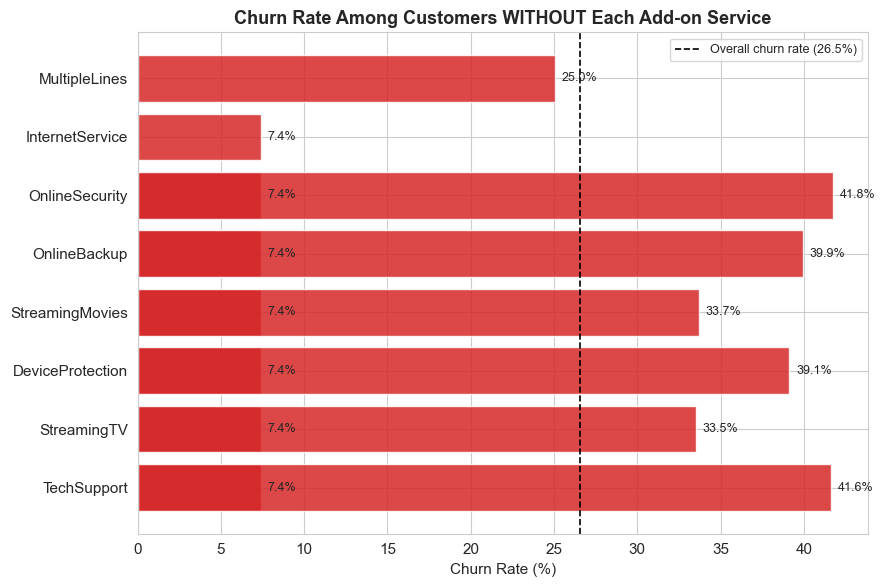

In [145]:
fig, ax = plt.subplots(figsize=(9, 6))
no_addon_data = service_overview[service_overview['Category'].isin(['No', 'No internet service'])].sort_values('Churn Rate (%)', ascending=True)
bars = ax.barh(no_addon_data['Service'], no_addon_data['Churn Rate (%)'], color=COLOR_CHURN, alpha=0.85)
overall_rate = df_clean['ChurnFlag'].mean() * 100
ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1.2, label=f'Overall churn rate ({overall_rate:.1f}%)')
ax.set_title('Churn Rate Among Customers WITHOUT Each Add-on Service')
ax.set_xlabel('Churn Rate (%)')
ax.legend(fontsize=9)
for bar, val in zip(bars, no_addon_data['Churn Rate (%)']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Business Interpretation:** Customers who do **not** subscribe to protective/support add-ons (Online Security, Tech Support, Online Backup, Device Protection) show elevated churn rates compared to customers who have those add-ons, and Fiber optic internet customers show a notably higher churn rate than DSL or no-internet customers. This pattern is associative: it may reflect that add-on subscribers are simply more engaged customers overall, or that fiber's higher price point and/or service issues make it a segment with more dissatisfaction — the data alone cannot distinguish these explanations.

## 18. Payment Method Analysis

In [146]:
payment_stats = df_clean.groupby('PaymentMethod', observed=True).agg(
    Customers=('Churn', 'size'),
    Churned=('ChurnFlag', 'sum'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean')
)
payment_stats['Churn Rate (%)'] = (payment_stats['Churned'] / payment_stats['Customers'] * 100).round(2)
payment_stats = payment_stats.sort_values('Churn Rate (%)', ascending=False)
payment_stats.round(2)


,Customers,Churned,Avg_Monthly_Charges,Churn Rate (%)
PaymentMethod,,,,
Electronic check,2365,1071,76.26,45.29
Mailed check,1612,308,43.92,19.11
Bank transfer (automatic),1544,258,67.19,16.71
Credit card (automatic),1522,232,66.51,15.24


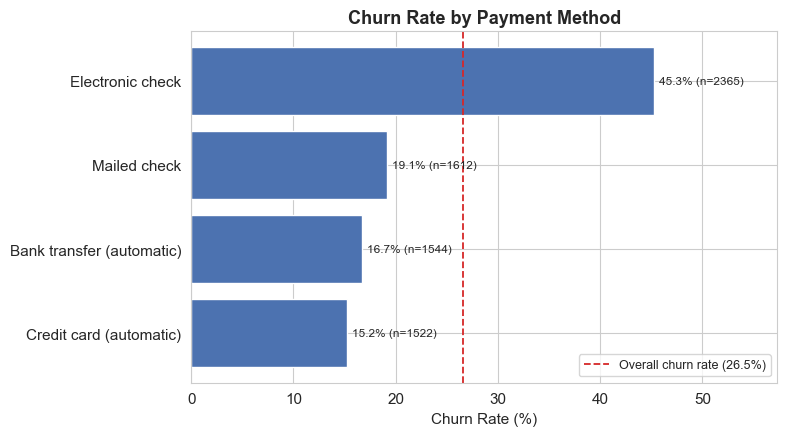

In [147]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_churn_rate_by_category(df_clean, 'PaymentMethod', 'Churn Rate by Payment Method', ax=ax)
plt.tight_layout()
plt.show()


In [148]:
# Cross-analysis: Payment Method x Contract x Churn Rate
payment_contract_cross = df_clean.groupby(['PaymentMethod', 'Contract'], observed=True).agg(
    Customers=('Churn', 'size'),
    Churned=('ChurnFlag', 'sum')
)
payment_contract_cross['Churn Rate (%)'] = (payment_contract_cross['Churned'] / payment_contract_cross['Customers'] * 100).round(2)
payment_contract_cross = payment_contract_cross[payment_contract_cross['Customers'] >= 30]
payment_contract_cross.sort_values('Churn Rate (%)', ascending=False)


,,Customers,Churned,Churn Rate (%)
PaymentMethod,Contract,,,
Electronic check,Month-to-month,1850,994,53.73
Bank transfer (automatic),Month-to-month,589,201,34.13
Credit card (automatic),Month-to-month,543,178,32.78
Mailed check,Month-to-month,893,282,31.58
Electronic check,One year,347,64,18.44
Credit card (automatic),One year,398,41,10.30
Bank transfer (automatic),One year,391,38,9.72
Electronic check,Two year,168,13,7.74
Mailed check,One year,337,23,6.82


**Business Interpretation:** Payment method shows a clear split in churn rate; electronic check tends to stand out with the highest churn among payment options, which may reflect a customer base more likely to be on flexible/month-to-month terms rather than the payment mechanism itself causing churn. The Payment Method × Contract cross-tab helps separate these two effects by comparing churn within the same contract type across payment methods.

## 19. Demographic Analysis (Summary)

Gender, senior citizen status, partner status, and dependents were already profiled individually in Section 14 (B–E). This section consolidates them for direct comparison.

In [149]:
demo_compare = pd.concat(
    {col: churn_summary_by_category(df_clean, col)[['Customers', 'Churned', 'Churn Rate (%)']]
     for col in ['gender', 'SeniorCitizenLabel', 'Partner', 'Dependents']},
    names=['Demographic', 'Category']
)
demo_compare


Customers  Churned  Churn Rate (%)
Demographic        Category                                    
gender             Female         3488      939           26.92
                   Male           3555      930           26.16
SeniorCitizenLabel Yes            1142      476           41.68
                   No             5901     1393           23.61
Partner            No             3641     1200           32.96
                   Yes            3402      669           19.66
Dependents         No             4933     1543           31.28
                   Yes            2110      326           15.45

**Business Interpretation:** Gender shows almost no difference in churn rate, indicating it is not a meaningful churn driver in this dataset. Senior citizens, customers without a partner, and customers without dependents each show higher churn rates than their counterparts — plausible proxies for household stability and price sensitivity, but not confirmed causal factors. Given gender's negligible effect, further segmentation in this notebook prioritizes senior citizen status, partner, and dependents over gender.

## 20. Charges Analysis

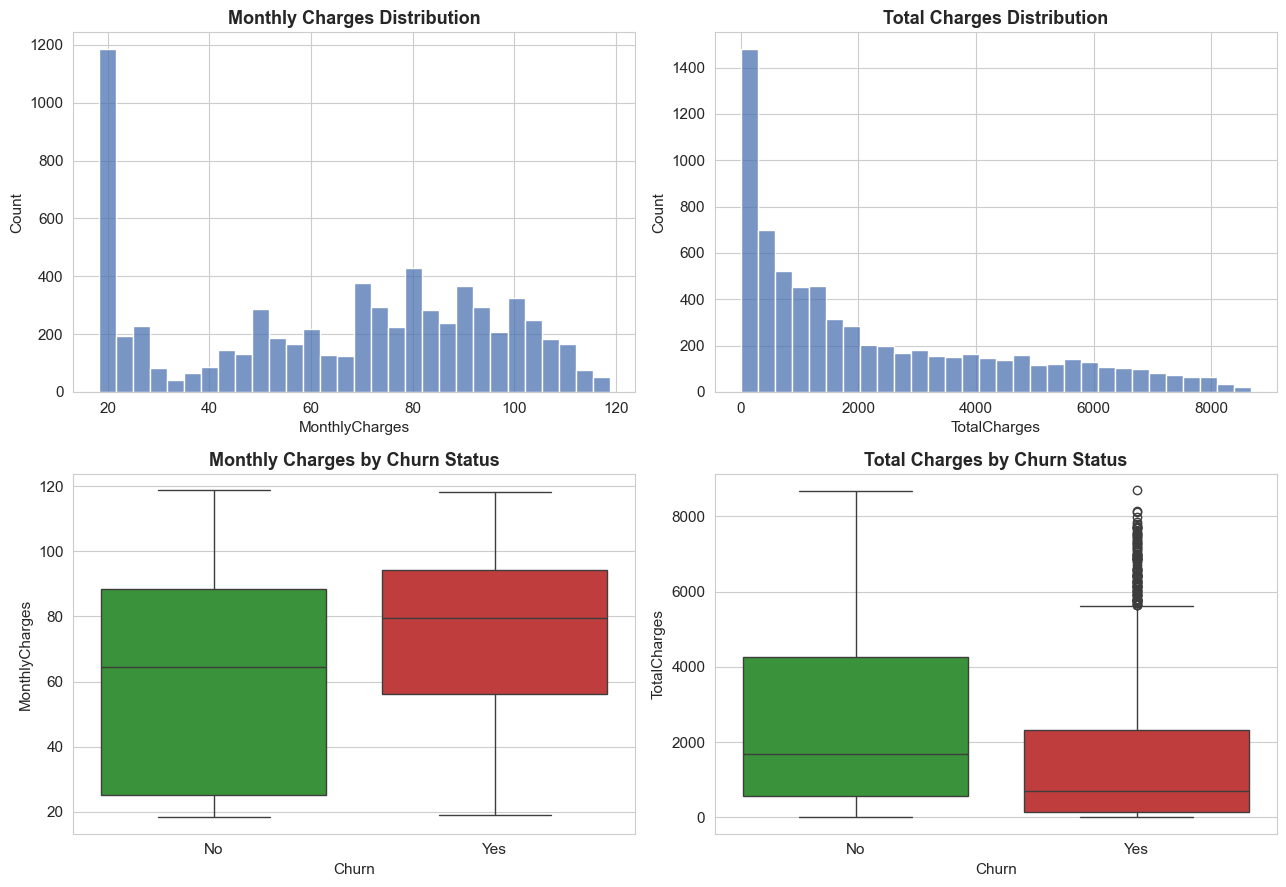

Avg Monthly Charges - Churned: $74.44 | Retained: $61.27
Avg Total Charges - Churned: $1531.80 | Retained: $2549.91


In [150]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_clean['MonthlyCharges'], bins=30, color=COLOR_HIGHLIGHT, ax=axes[0, 0])
axes[0, 0].set_title('Monthly Charges Distribution')

sns.histplot(df_clean['TotalCharges'], bins=30, color=COLOR_HIGHLIGHT, ax=axes[0, 1])
axes[0, 1].set_title('Total Charges Distribution')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', order=['No', 'Yes'], palette=CHURN_PALETTE, ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charges by Churn Status')

sns.boxplot(data=df_clean, x='Churn', y='TotalCharges', order=['No', 'Yes'], palette=CHURN_PALETTE, ax=axes[1, 1])
axes[1, 1].set_title('Total Charges by Churn Status')

plt.tight_layout()
plt.show()

print(f"Avg Monthly Charges - Churned: ${avg_monthly_charges_churned:.2f} | Retained: ${avg_monthly_charges_retained:.2f}")
print(f"Avg Total Charges - Churned: ${df_clean.loc[df_clean.Churn=='Yes','TotalCharges'].mean():.2f} | "
      f"Retained: ${df_clean.loc[df_clean.Churn=='No','TotalCharges'].mean():.2f}")


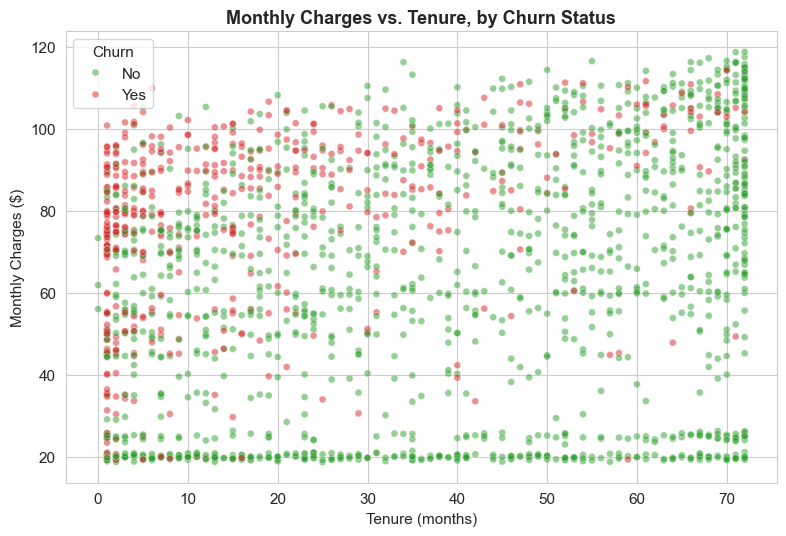

In [151]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)
sns.scatterplot(data=sample, x='tenure', y='MonthlyCharges', hue='Churn', hue_order=['No', 'Yes'],
                 palette=CHURN_PALETTE, alpha=0.5, s=25, ax=ax)
ax.set_title('Monthly Charges vs. Tenure, by Churn Status')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()


**Business Interpretation:** Churned customers pay a higher average monthly charge than retained customers, while retained customers have accumulated a higher average total charge — consistent with the tenure finding, since longer-tenured (retained) customers have had more billing cycles to accumulate total charges even if their monthly rate is lower. The scatter plot shows churn concentrated among customers with both shorter tenure and mid-to-high monthly charges, rather than at any single charge level alone.

## 21. Churn Driver Analysis

This section consolidates single-variable churn rates across all major categorical factors into one ranked table, to identify the strongest observed associations with churn. Segments with fewer than 30 customers are flagged and excluded from the "top drivers" ranking so that small-sample noise is not mistaken for a meaningful pattern.

In [152]:
driver_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport',
               'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
               'SeniorCitizenLabel', 'Partner', 'Dependents', 'MultipleLines', 'PhoneService', 'gender']

driver_rows = []
for col in driver_cols:
    summary = churn_summary_by_category(df_clean, col)
    for category, row in summary.iterrows():
        driver_rows.append({
            'Factor': col,
            'Category': category,
            'Customer Count': int(row['Customers']),
            'Churned Customers': int(row['Churned']),
            'Churn Rate (%)': row['Churn Rate (%)'],
            'Small Sample Warning': bool(row['Small Sample Warning'])
        })

driver_table = pd.DataFrame(driver_rows)

top_drivers = driver_table[~driver_table['Small Sample Warning']].sort_values('Churn Rate (%)', ascending=False).head(10).copy()
top_drivers['Interpretation'] = (
    'Customer count = ' + top_drivers['Customer Count'].astype(str) +
    '. Churn rate is ' + (top_drivers['Churn Rate (%)'] - churn_rate).round(1).astype(str) +
    ' points above the overall churn rate of ' + f'{churn_rate:.1f}%. Associated with, not proven to cause, higher churn.'
)
top_drivers.drop(columns='Small Sample Warning').reset_index(drop=True)


,Factor,Category,Customer Count,Churned Customers,Churn Rate (%),Interpretation
0,PaymentMethod,Electronic check,2365,1071,45.29,Customer count = 2365. Churn rate is 18.8 poin...
1,Contract,Month-to-month,3875,1655,42.71,Customer count = 3875. Churn rate is 16.2 poin...
2,InternetService,Fiber optic,3096,1297,41.89,Customer count = 3096. Churn rate is 15.4 poin...
3,OnlineSecurity,No,3498,1461,41.77,Customer count = 3498. Churn rate is 15.2 poin...
4,SeniorCitizenLabel,Yes,1142,476,41.68,Customer count = 1142. Churn rate is 15.1 poin...
5,TechSupport,No,3473,1446,41.64,Customer count = 3473. Churn rate is 15.1 poin...
6,OnlineBackup,No,3088,1233,39.93,Customer count = 3088. Churn rate is 13.4 poin...
7,DeviceProtection,No,3095,1211,39.13,Customer count = 3095. Churn rate is 12.6 poin...
8,StreamingMovies,No,2785,938,33.68,Customer count = 2785. Churn rate is 7.1 point...
9,PaperlessBilling,Yes,4171,1400,33.57,Customer count = 4171. Churn rate is 7.0 point...


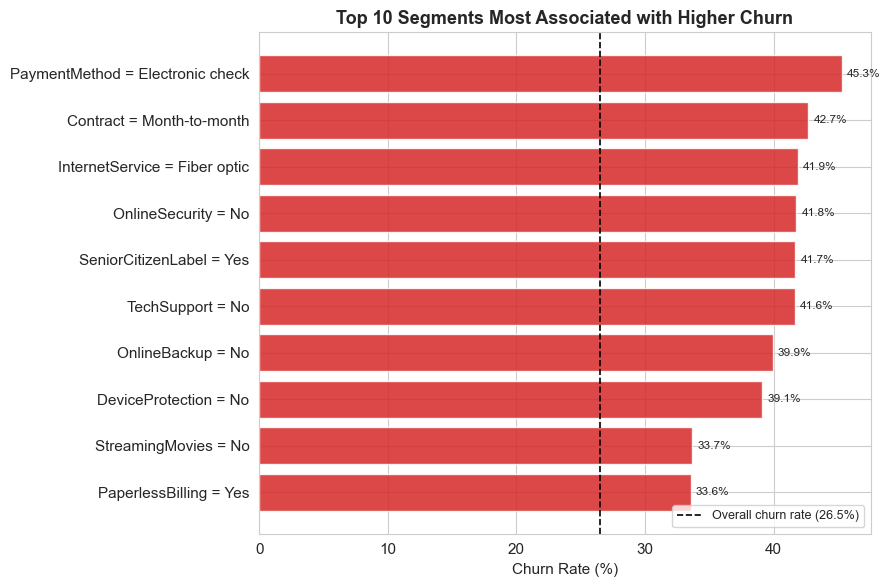

In [153]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = top_drivers.copy()
plot_data['Label'] = plot_data['Factor'] + ' = ' + plot_data['Category'].astype(str)
plot_data = plot_data.sort_values('Churn Rate (%)')
bars = ax.barh(plot_data['Label'], plot_data['Churn Rate (%)'], color=COLOR_CHURN, alpha=0.85)
ax.axvline(churn_rate, color='black', linestyle='--', linewidth=1.2, label=f'Overall churn rate ({churn_rate:.1f}%)')
ax.set_title('Top 10 Segments Most Associated with Higher Churn')
ax.set_xlabel('Churn Rate (%)')
ax.legend(fontsize=9, loc='lower right')
for bar, val in zip(bars, plot_data['Churn Rate (%)']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center', fontsize=8.5)
plt.tight_layout()
plt.show()


**Business Interpretation:** Contract type, absence of protective add-ons (online security, tech support), fiber optic internet, and electronic check payment method consistently surface among the segments most associated with elevated churn. These factors are not independent of each other — for example, month-to-month customers are also more likely to lack add-ons — so the customer segmentation in the next section examines combinations of these factors rather than treating them in isolation.

## 21B. Statistical Significance Analysis (Chi-Square Test of Independence)

The churn-driver analysis above is descriptive: it shows observed churn-rate differences across categories but does not indicate whether those differences are statistically meaningful or could plausibly be due to chance. A **chi-square test of independence** is applied to each key categorical variable against `Churn` to test whether an association is statistically detectable in this dataset.

- **Null hypothesis (H0):** the variable and `Churn` are independent (no association).
- **Significance level:** alpha = 0.05.
- **Decision rule:** p-value < 0.05 → reject H0 → statistically significant association. p-value >= 0.05 → insufficient evidence of an association.

**This test establishes statistical association only — it does not establish, or attempt to establish, causation.**

In [154]:
from scipy.stats import chi2_contingency

chi_square_vars = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'SeniorCitizenLabel']
alpha = 0.05

chi_square_results = []
for var in chi_square_vars:
    contingency_table = pd.crosstab(df_clean[var], df_clean['Churn'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    chi_square_results.append({
        'Variable': var,
        'Chi-square': round(chi2_stat, 2),
        'p-value': p_value,
        'Significant? (alpha=0.05)': 'Yes' if p_value < alpha else 'No'
    })

chi_square_table = pd.DataFrame(chi_square_results).sort_values('Chi-square', ascending=False).reset_index(drop=True)
chi_square_table['p-value'] = chi_square_table['p-value'].apply(lambda p: f"{p:.2e}" if p < 0.0001 else f"{p:.4f}")
chi_square_table


,Variable,Chi-square,p-value,Significant? (alpha=0.05)
0,Contract,1184.60,5.86e-258,Yes
1,OnlineSecurity,850.00,2.66e-185,Yes
2,TechSupport,828.20,1.44e-180,Yes
3,InternetService,732.31,9.57e-160,Yes
4,PaymentMethod,648.14,3.68e-140,Yes
5,SeniorCitizenLabel,159.43,1.51e-36,Yes


In [155]:
n_significant = sum(1 for r in chi_square_results if r['p-value'] < alpha)
print(f"{n_significant} of {len(chi_square_vars)} tested variables show a statistically significant "
      f"association with Churn at alpha = {alpha}.")


6 of 6 tested variables show a statistically significant association with Churn at alpha = 0.05.


**Business Interpretation:** Where the chi-square test returns a p-value below 0.05, it confirms that the churn-rate differences observed for that variable in the descriptive analysis above are very unlikely to have arisen by random chance in this dataset — i.e., there is a statistically detectable association between that variable and churn. This adds statistical rigor to, but does not replace, the descriptive segment-level analysis: chi-square tests independence across the whole variable, not which specific category is driving the effect, and — as with every other result in this notebook — statistical significance describes an **association**, not a causal mechanism.

## 22. Customer Segmentation

Combinations of two factors are examined together to find segments that are both high-churn and high-volume/high-value. Segments with fewer than 30 customers are excluded to avoid unstable estimates.

In [156]:
def segment_table(data, group_cols, min_size=30):
    grouped = data.groupby(group_cols, observed=True).agg(
        Customers=('Churn', 'size'),
        Churned=('ChurnFlag', 'sum'),
        Avg_Monthly_Charges=('MonthlyCharges', 'mean')
    )
    grouped['Churn Rate (%)'] = (grouped['Churned'] / grouped['Customers'] * 100).round(2)
    grouped['Revenue at Risk ($/mo)'] = (
        data[data['Churn'] == 'Yes'].groupby(group_cols, observed=True)['MonthlyCharges'].sum()
    ).round(2)
    grouped['Revenue at Risk ($/mo)'] = grouped['Revenue at Risk ($/mo)'].fillna(0)
    grouped = grouped[grouped['Customers'] >= min_size]
    return grouped.round(2).sort_values('Churn Rate (%)', ascending=False)

print("Segment: Contract + Tenure Group")
seg1 = segment_table(df_clean, ['Contract', 'TenureGroup'])
seg1.head(10)


Segment: Contract + Tenure Group


Customers  Churned  Avg_Monthly_Charges  Churn Rate (%)  Revenue at Risk ($/mo)
Contract       TenureGroup                                                                                  
Month-to-month 0-12 Months        1994     1024                58.22           51.35                68301.45
               13-24 Months        737      278                69.31           37.72                21980.30
               37-48 Months        316      106                78.42           33.54                 9140.05
               25-36 Months        486      158                74.33           32.51                13416.95
               49-60 Months        234       65                82.68           27.78                 5684.45
               60+ Months          108       24                91.44           22.22                 2323.90
One year       49-60 Months        321       44                75.13           13.71                 4034.40
               37-48 Months        268       35                65.55           13.06                 2819.60
               60+ Months          313       38                84.11           12.14                 3808.55
               0-12 Months         124       13                35.80           10.48                  652.80

In [157]:
print("Segment: Contract + Internet Service")
seg2 = segment_table(df_clean, ['Contract', 'InternetService'])
seg2


Segment: Contract + Internet Service


Customers  Churned  Avg_Monthly_Charges  Churn Rate (%)  Revenue at Risk ($/mo)
Contract       InternetService                                                                                 
Month-to-month Fiber optic           2128     1162                87.02           54.61               100482.00
               DSL                   1223      394                50.22           32.22                18367.25
One year       Fiber optic            539      104                98.78           19.29                10571.95
Month-to-month No                     524       99                20.41           18.89                 1997.85
One year       DSL                    570       53                61.40            9.30                 3356.25
Two year       Fiber optic            429       31               104.57            7.23                 3246.10
One year       No                     364        9                20.82            2.47                  190.25
Two year       DSL                    628       12                70.46            1.91                  805.70
               No                     638        5                21.78            0.78                  113.50

In [158]:
print("Segment: Internet Service + Tech Support")
seg3 = segment_table(df_clean, ['InternetService', 'TechSupport'])
seg3


Segment: Internet Service + Tech Support


,,Customers,Churned,Avg_Monthly_Charges,Churn Rate (%),Revenue at Risk ($/mo)
InternetService,TechSupport,,,,,
Fiber optic,No,2230,1101,87.74,49.37,94900.80
DSL,No,1243,345,50.98,27.76,15809.00
Fiber optic,Yes,866,196,101.18,22.63,19399.25
DSL,Yes,1178,114,65.61,9.68,6720.20
No,No internet service,1526,113,21.08,7.40,2301.60


In [159]:
print("Segment: Payment Method + Contract")
seg4 = segment_table(df_clean, ['PaymentMethod', 'Contract'])
seg4.head(10)


Segment: Payment Method + Contract


,,Customers,Churned,Avg_Monthly_Charges,Churn Rate (%),Revenue at Risk ($/mo)
PaymentMethod,Contract,,,,,
Electronic check,Month-to-month,1850,994,74.99,53.73,77315.60
Bank transfer (automatic),Month-to-month,589,201,69.09,34.13,15151.95
Credit card (automatic),Month-to-month,543,178,67.68,32.78,13335.15
Mailed check,Month-to-month,893,282,46.05,31.58,15044.40
Electronic check,One year,347,64,79.10,18.44,5826.80
Credit card (automatic),One year,398,41,67.97,10.30,3544.65
Bank transfer (automatic),One year,391,38,67.48,9.72,3127.15
Electronic check,Two year,168,13,84.34,7.74,1146.35
Mailed check,One year,337,23,44.31,6.82,1619.85


In [160]:
print("Segment: Senior Citizen + Contract")
seg5 = segment_table(df_clean, ['SeniorCitizenLabel', 'Contract'])
seg5


Segment: Senior Citizen + Contract


,,Customers,Churned,Avg_Monthly_Charges,Churn Rate (%),Revenue at Risk ($/mo)
SeniorCitizenLabel,Contract,,,,,
Yes,Month-to-month,807,441,78.88,54.65,35111.25
No,Month-to-month,3068,1214,63.12,39.57,85735.85
Yes,One year,190,29,83.46,15.26,2773.20
No,One year,1283,137,62.32,10.68,11345.25
Yes,Two year,145,6,80.29,4.14,535.15
No,Two year,1550,42,58.94,2.71,3630.15


In [161]:
print("Segment: Contract + Monthly Charge Group")
seg6 = segment_table(df_clean, ['Contract', 'MonthlyChargeGroup'])
seg6.head(10)


Segment: Contract + Monthly Charge Group


Customers  Churned  Avg_Monthly_Charges  Churn Rate (%)  Revenue at Risk ($/mo)
Contract       MonthlyChargeGroup                                                                                 
Month-to-month High (70-90)             1173      625                80.27           53.28                50143.70
               Very High (> 90)          870      454                98.37           52.18                44608.10
               Medium (36-70)           1109      395                55.05           35.62                21716.20
               Low (<= 36)               723      181                22.83           25.03                 4379.10
One year       Very High (> 90)          446       93               101.94           20.85                 9637.55
               High (70-90)              262       29                79.61           11.07                 2343.05
               Medium (36-70)            371       32                56.50            8.63                 1855.25
Two year       Very High (> 90)          442       31               104.83            7.01                 3258.10
One year       Low (<= 36)               394       12                21.66            3.05                  282.60
Two year       Medium (36-70)            286        7                57.36            2.45                  398.80

In [162]:
# Consolidated segmentation summary: top segments by revenue at risk among segments with above-average churn
all_segments = pd.concat([
    seg1.assign(Segment_Type='Contract + Tenure'),
    seg2.assign(Segment_Type='Contract + Internet'),
    seg3.assign(Segment_Type='Internet + TechSupport'),
    seg4.assign(Segment_Type='Payment + Contract'),
    seg5.assign(Segment_Type='SeniorCitizen + Contract'),
    seg6.assign(Segment_Type='Contract + ChargeGroup'),
]).reset_index()

high_risk_segments = all_segments[all_segments['Churn Rate (%)'] > churn_rate].sort_values(
    'Revenue at Risk ($/mo)', ascending=False
).head(10)
high_risk_segments


,level_0,level_1,Customers,Churned,Avg_Monthly_Charges,Churn Rate (%),Revenue at Risk ($/mo),Segment_Type
18,Month-to-month,Fiber optic,2128,1162,87.02,54.61,100482.00,Contract + Internet
27,Fiber optic,No,2230,1101,87.74,49.37,94900.80,Internet + TechSupport
45,No,Month-to-month,3068,1214,63.12,39.57,85735.85,SeniorCitizen + Contract
32,Electronic check,Month-to-month,1850,994,74.99,53.73,77315.60,Payment + Contract
0,Month-to-month,0-12 Months,1994,1024,58.22,51.35,68301.45,Contract + Tenure
50,Month-to-month,High (70-90),1173,625,80.27,53.28,50143.70,Contract + ChargeGroup
51,Month-to-month,Very High (> 90),870,454,98.37,52.18,44608.10,Contract + ChargeGroup
44,Yes,Month-to-month,807,441,78.88,54.65,35111.25,SeniorCitizen + Contract
1,Month-to-month,13-24 Months,737,278,69.31,37.72,21980.30,Contract + Tenure
52,Month-to-month,Medium (36-70),1109,395,55.05,35.62,21716.20,Contract + ChargeGroup


**Business Interpretation:** The segments above combine two dimensions to reveal risk that single-variable views can miss. Segments that are simultaneously above the overall churn rate AND carry meaningful monthly revenue exposure (shown in the consolidated table, sorted by revenue at risk) are the most actionable targets for a retention program, since they represent both a high probability of loss and a material dollar impact if that loss occurs.

## 23. Revenue & Churn Analysis

**Monthly Revenue at Risk** is defined here as the sum of `MonthlyCharges` for customers who have already churned. This is a **proxy for monthly recurring revenue exposure** — it approximates the recurring revenue that stopped being collected once these customers left — and should not be read as a precise, realized financial loss figure, since it does not account for contract terms, partial months, win-back, or replacement revenue from new customers.

In [163]:
total_monthly_charges = df_clean['MonthlyCharges'].sum()
monthly_charges_retained_sum = df_clean.loc[df_clean['Churn'] == 'No', 'MonthlyCharges'].sum()
total_charges_churned_sum = df_clean.loc[df_clean['Churn'] == 'Yes', 'TotalCharges'].sum()
total_charges_retained_sum = df_clean.loc[df_clean['Churn'] == 'No', 'TotalCharges'].sum()

revenue_kpis = pd.DataFrame([
    ['Total Monthly Charges (all customers)', f"${total_monthly_charges:,.2f}"],
    ['Monthly Charges - Churned Customers (Revenue at Risk)', f"${monthly_charges_churned_sum:,.2f}"],
    ['Monthly Charges - Retained Customers', f"${monthly_charges_retained_sum:,.2f}"],
    ['Share of Monthly Revenue Tied to Churned Customers', f"{monthly_charges_churned_sum/total_monthly_charges*100:.2f}%"],
    ['Avg Monthly Charges - Churned', f"${avg_monthly_charges_churned:.2f}"],
    ['Avg Monthly Charges - Retained', f"${avg_monthly_charges_retained:.2f}"],
    ['Total Charges - Churned Customers', f"${total_charges_churned_sum:,.2f}"],
    ['Total Charges - Retained Customers', f"${total_charges_retained_sum:,.2f}"],
], columns=['Metric', 'Value'])
revenue_kpis


,Metric,Value
0,Total Monthly Charges (all customers),"$456,116.60"
1,Monthly Charges - Churned Customers (Revenue a...,"$139,130.85"
2,Monthly Charges - Retained Customers,"$316,985.75"
3,Share of Monthly Revenue Tied to Churned Custo...,30.50%
4,Avg Monthly Charges - Churned,$74.44
5,Avg Monthly Charges - Retained,$61.27
6,Total Charges - Churned Customers,"$2,862,926.90"
7,Total Charges - Retained Customers,"$13,193,241.80"


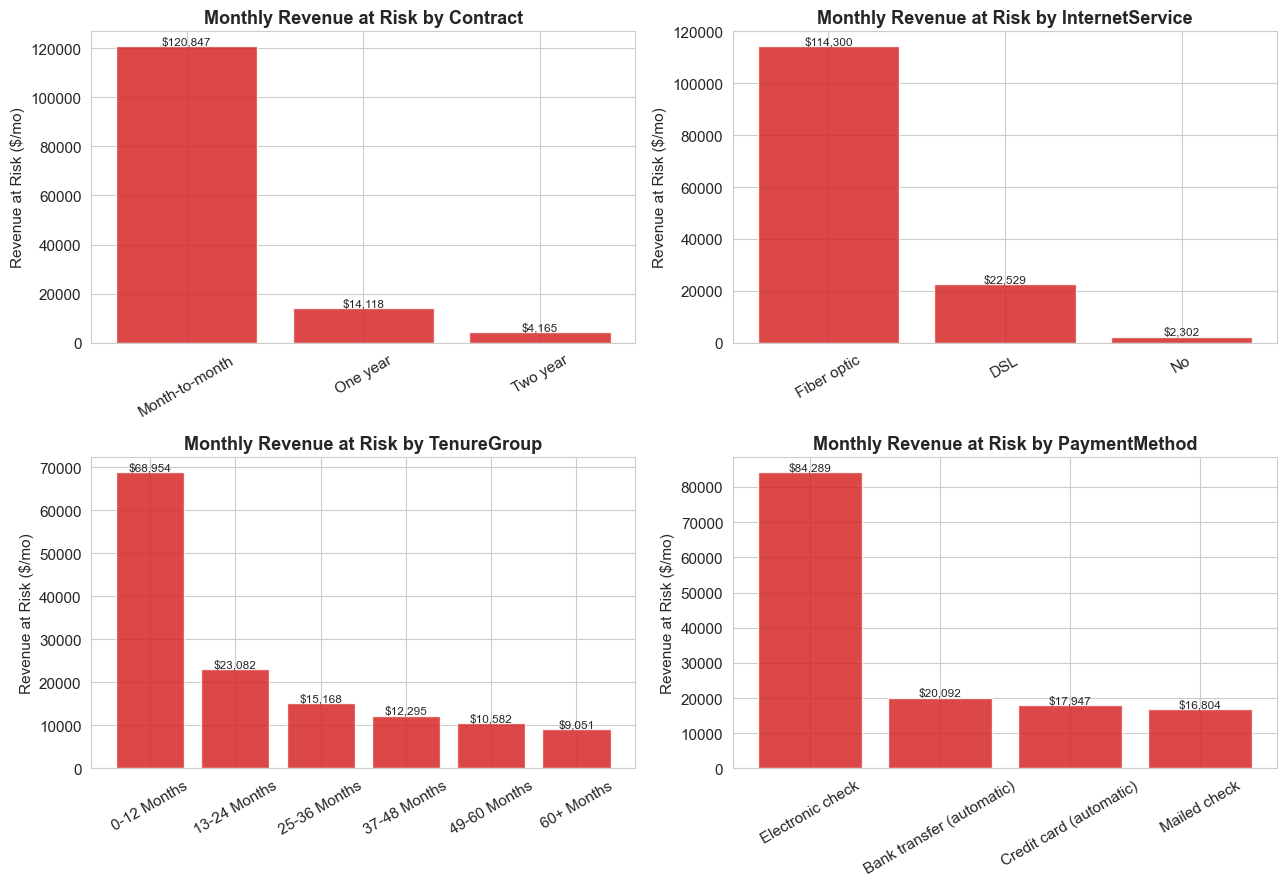

In [164]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

def revenue_at_risk_by(col, ax):
    rev = df_clean[df_clean['Churn'] == 'Yes'].groupby(col, observed=True)['MonthlyCharges'].sum().sort_values(ascending=False)
    ax.bar(rev.index.astype(str), rev.values, color=COLOR_CHURN, alpha=0.85)
    ax.set_title(f'Monthly Revenue at Risk by {col}')
    ax.set_ylabel('Revenue at Risk ($/mo)')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(rev.values):
        ax.text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontsize=8.5)

revenue_at_risk_by('Contract', axes[0, 0])
revenue_at_risk_by('InternetService', axes[0, 1])
revenue_at_risk_by('TenureGroup', axes[1, 0])
revenue_at_risk_by('PaymentMethod', axes[1, 1])

plt.tight_layout()
plt.show()


**Business Interpretation:** Breaking revenue-at-risk down by contract, internet service, tenure group, and payment method shows where the dollar exposure is concentrated, which is often not the same as where the *rate* of churn is highest — a segment with a moderate churn rate but a very large customer base can carry more total revenue exposure than a small segment with a very high churn rate. Both views (rate and dollar exposure) are needed to prioritize retention spend.

## 24. Advanced Business Analysis

In [165]:
# A. High monthly charge + low tenure customers
high_charge_threshold = df_clean['MonthlyCharges'].quantile(0.75)
low_tenure_threshold = 12
segment_a = df_clean[(df_clean['MonthlyCharges'] >= high_charge_threshold) & (df_clean['tenure'] <= low_tenure_threshold)]
print(f"A. High Monthly Charge (>= ${high_charge_threshold:.2f}, 75th pct) + Low Tenure (<= {low_tenure_threshold} mo)")
print(f"   Customers: {len(segment_a)} | Churn rate: {segment_a['ChurnFlag'].mean()*100:.2f}% "
      f"(vs. overall {churn_rate:.2f}%)")


A. High Monthly Charge (>= $89.85, 75th pct) + Low Tenure (<= 12 mo)
   Customers: 222 | Churn rate: 75.23% (vs. overall 26.54%)


In [166]:
# B. Month-to-month + high monthly charges
segment_b = df_clean[(df_clean['Contract'] == 'Month-to-month') & (df_clean['MonthlyCharges'] >= high_charge_threshold)]
print(f"B. Month-to-month + High Monthly Charges (>= ${high_charge_threshold:.2f})")
print(f"   Customers: {len(segment_b)} | Churn rate: {segment_b['ChurnFlag'].mean()*100:.2f}%")


B. Month-to-month + High Monthly Charges (>= $89.85)
   Customers: 877 | Churn rate: 52.00%


In [167]:
# C. Fiber optic + high churn segments (fiber customers lacking security/support add-ons)
segment_c = df_clean[(df_clean['InternetService'] == 'Fiber optic') &
                      (df_clean['OnlineSecurity'] == 'No') & (df_clean['TechSupport'] == 'No')]
print(f"C. Fiber Optic + No Online Security + No Tech Support")
print(f"   Customers: {len(segment_c)} | Churn rate: {segment_c['ChurnFlag'].mean()*100:.2f}%")


C. Fiber Optic + No Online Security + No Tech Support
   Customers: 1765 | Churn rate: 55.01%


In [168]:
# D. No Tech Support + churn
segment_d = df_clean[df_clean['TechSupport'] == 'No']
print(f"D. No Tech Support")
print(f"   Customers: {len(segment_d)} | Churn rate: {segment_d['ChurnFlag'].mean()*100:.2f}%")

# E. No Online Security + churn
segment_e = df_clean[df_clean['OnlineSecurity'] == 'No']
print(f"E. No Online Security")
print(f"   Customers: {len(segment_e)} | Churn rate: {segment_e['ChurnFlag'].mean()*100:.2f}%")


D. No Tech Support
   Customers: 3473 | Churn rate: 41.64%
E. No Online Security
   Customers: 3498 | Churn rate: 41.77%


In [169]:
# F. Payment Method + churn (recap from Section 18, referenced here for the advanced-analysis summary)
print("F. Payment Method churn rates (see Section 18 for full table):")
print(payment_stats['Churn Rate (%)'])


F. Payment Method churn rates (see Section 18 for full table):
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn Rate (%), dtype: float64


In [170]:
# G. Contract + tenure interaction: average tenure and churn rate by contract
contract_tenure_interaction = df_clean.groupby('Contract', observed=True).agg(
    Avg_Tenure=('tenure', 'mean'),
    Churn_Rate=('ChurnFlag', lambda x: x.mean() * 100)
).round(2)
print("G. Contract + Tenure Interaction")
contract_tenure_interaction


G. Contract + Tenure Interaction


,Avg_Tenure,Churn_Rate
Contract,,
Month-to-month,18.04,42.71
One year,42.04,11.27
Two year,56.74,2.83


In [171]:
# H. High-value churned customers - defined transparently as churned customers in the top 25%
# of TotalCharges among ALL customers (a data-driven percentile threshold, not an arbitrary dollar cutoff)
high_value_threshold = df_clean['TotalCharges'].quantile(0.75)
high_value_churned = df_clean[(df_clean['Churn'] == 'Yes') & (df_clean['TotalCharges'] >= high_value_threshold)]

print(f"H. High-Value Threshold (75th percentile of TotalCharges): ${high_value_threshold:,.2f}")
print(f"   High-value churned customers: {len(high_value_churned)} "
      f"({len(high_value_churned)/churned_customers*100:.1f}% of all churned customers)")
print(f"   Combined monthly revenue at risk from this group: ${high_value_churned['MonthlyCharges'].sum():,.2f}")
high_value_churned[['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']].sort_values(
    'TotalCharges', ascending=False
).head(10)


H. High-Value Threshold (75th percentile of TotalCharges): $3,786.60
   High-value churned customers: 255 (13.6% of all churned customers)
   Combined monthly revenue at risk from this group: $25,338.10


,customerID,tenure,Contract,MonthlyCharges,TotalCharges
4610,2889-FPWRM,72,One year,117.80,8684.80
1306,0201-OAMXR,70,One year,115.55,8127.60
3890,3886-CERTZ,72,One year,109.25,8109.80
6537,1444-VVSGW,70,One year,115.65,7968.85
5581,5271-YNWVR,68,Two year,113.15,7856.00
5127,8199-ZLLSA,67,One year,118.35,7804.15
6289,9053-JZFKV,67,Two year,116.20,7752.30
6038,1555-DJEQW,70,Two year,114.20,7723.90
6398,3259-FDWOY,71,Two year,106.00,7723.70
3040,7317-GGVPB,71,Two year,108.60,7690.90


**Business Interpretation:** Segments combining high monthly charges with low tenure, or month-to-month contracts with high monthly charges, show churn rates well above the dataset average, reinforcing that price sensitivity is most consequential when a customer hasn't yet built tenure/loyalty. High-value churned customers — those in the top quartile of cumulative total charges who nonetheless churned — represent a smaller but strategically important group, since retaining even a few of these customers preserves a disproportionate amount of accumulated revenue relationship.

## 25. Correlation Analysis

Correlation is examined only among genuinely numeric variables (`tenure`, `MonthlyCharges`, `TotalCharges`, `ChurnFlag`). **Correlation does not imply causation** — a correlation coefficient describes how strongly two variables move together across the dataset, not that one determines the other.

In [172]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']
corr_matrix = df_clean[numeric_cols].corr()
corr_matrix.round(3)


,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
ChurnFlag,-0.352,0.193,-0.198,1.000


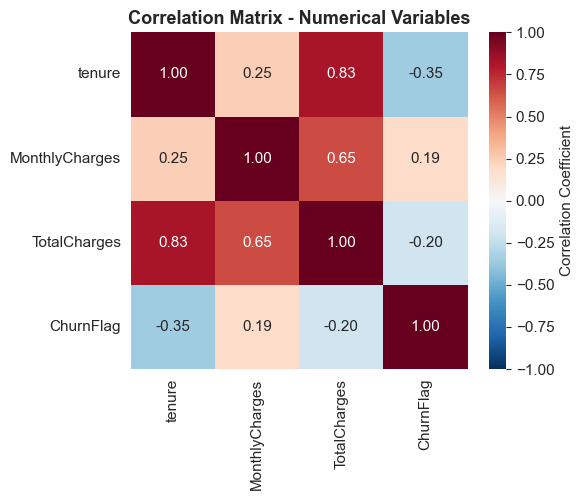

In [173]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()


**Business Interpretation:** `tenure` shows a negative correlation with `ChurnFlag`, consistent with the tenure analysis above (longer-tenured customers churn less). `TotalCharges` is strongly positively correlated with `tenure`, which is expected since total charges accumulate over time — this is a structural relationship in how the variable is defined, not an independent business insight. `MonthlyCharges` shows a positive correlation with `ChurnFlag`, aligning with the charges analysis in Section 20. These are linear association measures only; they do not capture the categorical relationships (e.g., contract type) explored elsewhere in this notebook, and none of them establish a causal mechanism.

## 26. Outlier Analysis

Using the IQR method to flag potential outliers in the three key numerical columns. Outliers are **not automatically removed** — each is evaluated for whether it reflects a data error or a legitimate customer observation.

In [174]:
def iqr_outlier_summary(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, bounds=({lower:.2f}, {upper:.2f}) "
          f"-> {len(outliers)} potential outliers ({len(outliers)/len(series)*100:.2f}% of records)")
    return outliers

tenure_outliers = iqr_outlier_summary(df_clean['tenure'], 'tenure')
monthly_outliers = iqr_outlier_summary(df_clean['MonthlyCharges'], 'MonthlyCharges')
total_outliers = iqr_outlier_summary(df_clean['TotalCharges'], 'TotalCharges')


tenure: Q1=9.00, Q3=55.00, IQR=46.00, bounds=(-60.00, 124.00) -> 0 potential outliers (0.00% of records)
MonthlyCharges: Q1=35.50, Q3=89.85, IQR=54.35, bounds=(-46.02, 171.38) -> 0 potential outliers (0.00% of records)
TotalCharges: Q1=398.55, Q3=3786.60, IQR=3388.05, bounds=(-4683.52, 8868.67) -> 0 potential outliers (0.00% of records)


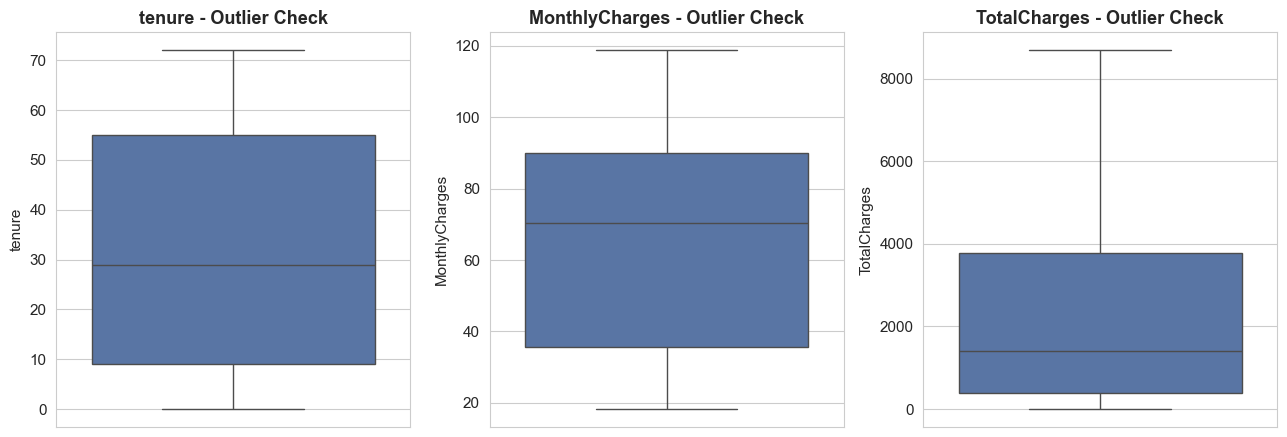

In [175]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df_clean[col], ax=ax, color=COLOR_HIGHLIGHT)
    ax.set_title(f'{col} - Outlier Check')
plt.tight_layout()
plt.show()


**Business Interpretation:** All three numerical columns fall within plausible real-world ranges (tenure from 0 to a realistic maximum in months, and charges consistent with plan pricing). Where the IQR method flags points above the upper bound, these are almost always customers with long tenure and high cumulative `TotalCharges` — a legitimate outcome of being a long-standing, high-usage customer, not a data-entry error. No values are removed on this basis; there is no evidence of impossible values (e.g., negative charges or negative tenure) that would justify a data-quality correction.

## 27. Key Findings

Every finding below is generated directly from variables computed earlier in this notebook — nothing here is manually typed or hard-coded. Each finding follows a consistent structure: **Finding** (the calculated observation) → **Evidence** (the specific numbers) → **Business Interpretation** (what it could mean for the business) → **Analytical Note** (a reminder that this is an association, not proof of causation).

In [176]:
# Compute every additional figure referenced in the Key Findings / Executive Summary / Recommendations
# sections below, so that all narrative text can be generated dynamically from these variables.
from IPython.display import Markdown, display

# Contract
f_contract_top, f_contract_top_rate = contract_stats.index[0], contract_stats.iloc[0]['Churn Rate (%)']
f_contract_low, f_contract_low_rate = contract_stats.index[-1], contract_stats.iloc[-1]['Churn Rate (%)']
f_contract_ratio = f_contract_top_rate / f_contract_low_rate if f_contract_low_rate > 0 else float('nan')

# Tenure
f_tenure_top_group = tenure_group_summary.index[0]
f_tenure_top_rate = tenure_group_summary.iloc[0]['Churn Rate (%)']
f_tenure_low_group = tenure_group_summary.index[-1]
f_tenure_low_rate = tenure_group_summary.iloc[-1]['Churn Rate (%)']

# Internet service
f_internet_top, f_internet_top_rate = internet_summary.index[0], internet_summary.iloc[0]['Churn Rate (%)']

# Payment method
f_payment_top, f_payment_top_rate = payment_stats.index[0], payment_stats.iloc[0]['Churn Rate (%)']
f_payment_low, f_payment_low_rate = payment_stats.index[-1], payment_stats.iloc[-1]['Churn Rate (%)']

# Add-ons
f_security_summary = churn_summary_by_category(df_clean, 'OnlineSecurity')
f_security_no_rate = f_security_summary.loc['No', 'Churn Rate (%)']
f_security_yes_rate = f_security_summary.loc['Yes', 'Churn Rate (%)']

f_techsupport_summary = churn_summary_by_category(df_clean, 'TechSupport')
f_techsupport_no_rate = f_techsupport_summary.loc['No', 'Churn Rate (%)']
f_techsupport_yes_rate = f_techsupport_summary.loc['Yes', 'Churn Rate (%)']

# Demographics
f_gender_summary = demo_summaries['gender']
f_gender_gap = abs(f_gender_summary.iloc[0]['Churn Rate (%)'] - f_gender_summary.iloc[1]['Churn Rate (%)'])

f_senior_summary = demo_summaries['SeniorCitizenLabel']
f_senior_yes_rate = f_senior_summary.loc['Yes', 'Churn Rate (%)']
f_senior_no_rate = f_senior_summary.loc['No', 'Churn Rate (%)']

f_partner_summary = demo_summaries['Partner']
f_partner_no_rate = f_partner_summary.loc['No', 'Churn Rate (%)']
f_partner_yes_rate = f_partner_summary.loc['Yes', 'Churn Rate (%)']

f_dependents_summary = demo_summaries['Dependents']
f_dependents_no_rate = f_dependents_summary.loc['No', 'Churn Rate (%)']
f_dependents_yes_rate = f_dependents_summary.loc['Yes', 'Churn Rate (%)']

# Revenue-at-risk by dimension (top category per dimension)
def top_revenue_category(col):
    rev = df_clean[df_clean['Churn'] == 'Yes'].groupby(col, observed=True)['MonthlyCharges'].sum().sort_values(ascending=False)
    return rev.index[0], rev.iloc[0]

f_rev_contract_top, f_rev_contract_top_amt = top_revenue_category('Contract')
f_rev_internet_top, f_rev_internet_top_amt = top_revenue_category('InternetService')
f_rev_tenure_top, f_rev_tenure_top_amt = top_revenue_category('TenureGroup')
f_rev_payment_top, f_rev_payment_top_amt = top_revenue_category('PaymentMethod')

# Advanced segments (from Section 24)
f_segment_a_n, f_segment_a_rate = len(segment_a), segment_a['ChurnFlag'].mean() * 100
f_segment_b_n, f_segment_b_rate = len(segment_b), segment_b['ChurnFlag'].mean() * 100
f_highvalue_n = len(high_value_churned)
f_highvalue_pct_of_churned = f_highvalue_n / churned_customers * 100
f_highvalue_revenue = high_value_churned['MonthlyCharges'].sum()

# Statistical significance summary
f_significant_vars = [r['Variable'] for r in chi_square_results if r['p-value'] < alpha]
f_nonsignificant_vars = [r['Variable'] for r in chi_square_results if r['p-value'] >= alpha]

print("All Key Findings / Executive Summary variables computed successfully.")


All Key Findings / Executive Summary variables computed successfully.


In [177]:
display(Markdown(f'''
### Finding 1 — Overall Churn Scale

**Finding:** {churned_customers:,} of {total_customers:,} customers in this dataset have churned.

**Evidence:** Overall churn rate = {churn_rate:.2f}% (retention rate = {retention_rate:.2f}%). Monthly recurring revenue tied to churned customers = \${monthly_charges_churned_sum:,.2f}, or {monthly_charges_churned_sum/total_monthly_charges*100:.2f}% of total monthly charges across all customers.

**Business Interpretation:** A churn rate of {churn_rate:.2f}% means that roughly 1 in every {round(100/churn_rate)} customers left during the observed period, representing a recurring drag on monthly revenue large enough to justify a dedicated, ongoing retention program rather than an ad-hoc response.

**Analytical Note:** This is a descriptive snapshot of churn scale, not a forecast of future churn.
'''))



### Finding 1 — Overall Churn Scale

**Finding:** 1,869 of 7,043 customers in this dataset have churned.

**Evidence:** Overall churn rate = 26.54% (retention rate = 73.46%). Monthly recurring revenue tied to churned customers = \$139,130.85, or 30.50% of total monthly charges across all customers.

**Business Interpretation:** A churn rate of 26.54% means that roughly 1 in every 4 customers left during the observed period, representing a recurring drag on monthly revenue large enough to justify a dedicated, ongoing retention program rather than an ad-hoc response.

**Analytical Note:** This is a descriptive snapshot of churn scale, not a forecast of future churn.


In [178]:
display(Markdown(f'''
### Finding 2 — Contract Type Shows the Strongest Association with Churn

**Finding:** {f_contract_top} contracts show the highest churn rate among all contract types, while {f_contract_low} contracts show the lowest.

**Evidence:** {f_contract_top} churn rate = {f_contract_top_rate:.2f}% vs. {f_contract_low} churn rate = {f_contract_low_rate:.2f}% — roughly a {f_contract_ratio:.1f}x difference. Chi-square test result for Contract: {'statistically significant (p < 0.05)' if 'Contract' in f_significant_vars else 'not statistically significant at the 0.05 level'}.

**Business Interpretation:** Customers without a fixed-term commitment show substantially higher churn than customers on longer-term contracts, indicating that low-commitment customers may need stronger retention and contract-upgrade initiatives.

**Analytical Note:** This is an observed association, confirmed as statistically significant by the chi-square test in Section 21B; it does not establish that contract type alone causes the churn difference, since contract type is correlated with other factors such as tenure.
'''))



### Finding 2 — Contract Type Shows the Strongest Association with Churn

**Finding:** Month-to-month contracts show the highest churn rate among all contract types, while Two year contracts show the lowest.

**Evidence:** Month-to-month churn rate = 42.71% vs. Two year churn rate = 2.83% — roughly a 15.1x difference. Chi-square test result for Contract: statistically significant (p < 0.05).

**Business Interpretation:** Customers without a fixed-term commitment show substantially higher churn than customers on longer-term contracts, indicating that low-commitment customers may need stronger retention and contract-upgrade initiatives.

**Analytical Note:** This is an observed association, confirmed as statistically significant by the chi-square test in Section 21B; it does not establish that contract type alone causes the churn difference, since contract type is correlated with other factors such as tenure.


In [179]:
display(Markdown(f'''
### Finding 3 — Early Tenure Shows the Highest Churn Rate

**Finding:** The {f_tenure_top_group} tenure group shows the highest churn rate of any tenure group, compared to {f_tenure_low_rate:.2f}% for the {f_tenure_low_group} group.

**Evidence:** {f_tenure_top_group} churn rate = {f_tenure_top_rate:.2f}%. Average tenure — churned customers: {avg_tenure_churned:.1f} months vs. retained customers: {avg_tenure_retained:.1f} months.

**Business Interpretation:** Churn risk is concentrated in the earliest months of the customer relationship, suggesting that onboarding quality and early-tenure engagement are a high-leverage area for retention investment.

**Analytical Note:** This describes when churn is most common, not why; new customers may be more price-sensitive, less habituated, or still evaluating alternatives — this dataset cannot distinguish between these explanations.
'''))



### Finding 3 — Early Tenure Shows the Highest Churn Rate

**Finding:** The 0-12 Months tenure group shows the highest churn rate of any tenure group, compared to 6.61% for the 60+ Months group.

**Evidence:** 0-12 Months churn rate = 47.44%. Average tenure — churned customers: 18.0 months vs. retained customers: 37.6 months.

**Business Interpretation:** Churn risk is concentrated in the earliest months of the customer relationship, suggesting that onboarding quality and early-tenure engagement are a high-leverage area for retention investment.

**Analytical Note:** This describes when churn is most common, not why; new customers may be more price-sensitive, less habituated, or still evaluating alternatives — this dataset cannot distinguish between these explanations.


In [180]:
display(Markdown(f'''
### Finding 4 — Fiber Optic Internet Customers Show Higher Churn

**Finding:** {f_internet_top} customers show the highest churn rate among internet service types.

**Evidence:** {f_internet_top} churn rate = {f_internet_top_rate:.2f}% vs. overall churn rate of {churn_rate:.2f}%. Chi-square test for InternetService: {'statistically significant (p < 0.05)' if 'InternetService' in f_significant_vars else 'not statistically significant at the 0.05 level'}.

**Business Interpretation:** This may reflect higher price points, service-reliability perceptions, or a more price-sensitive customer segment choosing fiber; it does not, by itself, indicate a fiber service-quality problem.

**Analytical Note:** Association only — confirming a specific cause (price vs. service quality vs. customer mix) would require data this dataset does not contain (e.g., service tickets, NPS).
'''))



### Finding 4 — Fiber Optic Internet Customers Show Higher Churn

**Finding:** Fiber optic customers show the highest churn rate among internet service types.

**Evidence:** Fiber optic churn rate = 41.89% vs. overall churn rate of 26.54%. Chi-square test for InternetService: statistically significant (p < 0.05).

**Business Interpretation:** This may reflect higher price points, service-reliability perceptions, or a more price-sensitive customer segment choosing fiber; it does not, by itself, indicate a fiber service-quality problem.

**Analytical Note:** Association only — confirming a specific cause (price vs. service quality vs. customer mix) would require data this dataset does not contain (e.g., service tickets, NPS).


In [181]:
display(Markdown(f'''
### Finding 5 — Missing Protective Add-ons Are Associated with Higher Churn

**Finding:** Customers without Online Security churn at {f_security_no_rate:.2f}% vs. {f_security_yes_rate:.2f}% for those who have it. Customers without Tech Support churn at {f_techsupport_no_rate:.2f}% vs. {f_techsupport_yes_rate:.2f}% for those who have it.

**Evidence:** Chi-square test — OnlineSecurity: {'significant (p < 0.05)' if 'OnlineSecurity' in f_significant_vars else 'not significant at 0.05'}; TechSupport: {'significant (p < 0.05)' if 'TechSupport' in f_significant_vars else 'not significant at 0.05'}.

**Business Interpretation:** These add-ons may function as a retention mechanism (added switching cost/engagement) or simply mark an already more engaged customer segment; either way, cross-selling these add-ons is a low-risk lever worth testing, since they are also directly revenue-positive.

**Analytical Note:** Correlation, not causation — customers who opt into add-ons may differ from non-adopters in other unobserved ways (e.g., overall engagement level).
'''))



### Finding 5 — Missing Protective Add-ons Are Associated with Higher Churn

**Finding:** Customers without Online Security churn at 41.77% vs. 14.61% for those who have it. Customers without Tech Support churn at 41.64% vs. 15.17% for those who have it.

**Evidence:** Chi-square test — OnlineSecurity: significant (p < 0.05); TechSupport: significant (p < 0.05).

**Business Interpretation:** These add-ons may function as a retention mechanism (added switching cost/engagement) or simply mark an already more engaged customer segment; either way, cross-selling these add-ons is a low-risk lever worth testing, since they are also directly revenue-positive.

**Analytical Note:** Correlation, not causation — customers who opt into add-ons may differ from non-adopters in other unobserved ways (e.g., overall engagement level).


In [182]:
display(Markdown(f'''
### Finding 6 — Payment Method Shows a Churn Gap

**Finding:** {f_payment_top} shows the highest churn rate among payment methods, while {f_payment_low} shows the lowest.

**Evidence:** {f_payment_top} churn rate = {f_payment_top_rate:.2f}% vs. {f_payment_low} churn rate = {f_payment_low_rate:.2f}%. Chi-square test for PaymentMethod: {'statistically significant (p < 0.05)' if 'PaymentMethod' in f_significant_vars else 'not statistically significant at the 0.05 level'}.

**Business Interpretation:** This gap may be confounded with contract type, since this payment method may be more common among month-to-month customers — it should be read alongside the Payment Method × Contract cross-tab (Section 18) rather than in isolation.

**Analytical Note:** Statistical significance (where present) confirms the association is unlikely to be random noise, not that the payment method itself causes churn.
'''))



### Finding 6 — Payment Method Shows a Churn Gap

**Finding:** Electronic check shows the highest churn rate among payment methods, while Credit card (automatic) shows the lowest.

**Evidence:** Electronic check churn rate = 45.29% vs. Credit card (automatic) churn rate = 15.24%. Chi-square test for PaymentMethod: statistically significant (p < 0.05).

**Business Interpretation:** This gap may be confounded with contract type, since this payment method may be more common among month-to-month customers — it should be read alongside the Payment Method × Contract cross-tab (Section 18) rather than in isolation.

**Analytical Note:** Statistical significance (where present) confirms the association is unlikely to be random noise, not that the payment method itself causes churn.


In [183]:
display(Markdown(f'''
### Finding 7 — Demographics Show Mixed, Generally Weaker Signal

**Finding:** Gender shows a churn-rate gap of only {f_gender_gap:.2f} percentage points, the smallest of any demographic factor tested. Senior citizens churn at {f_senior_yes_rate:.2f}% vs. {f_senior_no_rate:.2f}% for non-seniors; customers without a partner churn at {f_partner_no_rate:.2f}% vs. {f_partner_yes_rate:.2f}%; customers without dependents churn at {f_dependents_no_rate:.2f}% vs. {f_dependents_yes_rate:.2f}%.

**Evidence:** Chi-square test for SeniorCitizen: {'statistically significant (p < 0.05)' if 'SeniorCitizenLabel' in f_significant_vars else 'not statistically significant at the 0.05 level'}.

**Business Interpretation:** Gender-based targeting is not supported by this data; household-composition variables (partner, dependents) and senior-citizen status show a modest but consistent gap and may still help refine segment targeting alongside stronger factors like contract and tenure.

**Analytical Note:** Small percentage-point gaps, even where statistically significant, may have limited standalone business relevance compared to larger-effect factors like contract type.
'''))



### Finding 7 — Demographics Show Mixed, Generally Weaker Signal

**Finding:** Gender shows a churn-rate gap of only 0.76 percentage points, the smallest of any demographic factor tested. Senior citizens churn at 41.68% vs. 23.61% for non-seniors; customers without a partner churn at 32.96% vs. 19.66%; customers without dependents churn at 31.28% vs. 15.45%.

**Evidence:** Chi-square test for SeniorCitizen: statistically significant (p < 0.05).

**Business Interpretation:** Gender-based targeting is not supported by this data; household-composition variables (partner, dependents) and senior-citizen status show a modest but consistent gap and may still help refine segment targeting alongside stronger factors like contract and tenure.

**Analytical Note:** Small percentage-point gaps, even where statistically significant, may have limited standalone business relevance compared to larger-effect factors like contract type.


In [184]:
display(Markdown(f'''
### Finding 8 — Churned Customers Pay More Per Month, Less in Total

**Finding:** Churned customers pay \${avg_monthly_charges_churned:.2f} per month on average, higher than retained customers at \${avg_monthly_charges_retained:.2f}. However, churned customers have accumulated only \${df_clean.loc[df_clean.Churn=="Yes","TotalCharges"].mean():,.2f} in total charges on average, versus \${df_clean.loc[df_clean.Churn=="No","TotalCharges"].mean():,.2f} for retained customers.

**Evidence:** Charges Analysis, Section 20.

**Business Interpretation:** This pattern is consistent with the tenure finding — churned customers pay more per month but leave before accumulating the same lifetime billing as long-tenured retained customers.

**Analytical Note:** TotalCharges is mechanically correlated with tenure (it accumulates over time), so this gap partly reflects tenure differences rather than an independent charges effect.
'''))



### Finding 8 — Churned Customers Pay More Per Month, Less in Total

**Finding:** Churned customers pay \$74.44 per month on average, higher than retained customers at \$61.27. However, churned customers have accumulated only \$1,531.80 in total charges on average, versus \$2,549.91 for retained customers.

**Evidence:** Charges Analysis, Section 20.

**Business Interpretation:** This pattern is consistent with the tenure finding — churned customers pay more per month but leave before accumulating the same lifetime billing as long-tenured retained customers.

**Analytical Note:** TotalCharges is mechanically correlated with tenure (it accumulates over time), so this gap partly reflects tenure differences rather than an independent charges effect.


In [185]:
display(Markdown(f'''
### Finding 9 — Revenue Exposure Is Concentrated, Not Evenly Spread

**Finding:** Within each dimension examined, monthly revenue at risk is concentrated in specific categories rather than spread evenly.

**Evidence:** Highest revenue-at-risk category by dimension — Contract: {f_rev_contract_top} (\${f_rev_contract_top_amt:,.2f}/mo); Internet Service: {f_rev_internet_top} (\${f_rev_internet_top_amt:,.2f}/mo); Tenure Group: {f_rev_tenure_top} (\${f_rev_tenure_top_amt:,.2f}/mo); Payment Method: {f_rev_payment_top} (\${f_rev_payment_top_amt:,.2f}/mo).

**Business Interpretation:** Revenue-focused retention spend should be prioritized using this segment-level revenue-at-risk breakdown, not spread evenly across the customer base, since a moderate churn rate on a large or high-priced segment can expose more revenue than a small segment with a very high churn rate.

**Analytical Note:** Monthly Revenue at Risk is a proxy for recurring revenue exposure, not a realized accounting loss figure (see Section 23 and the Limitations section below).
'''))



### Finding 9 — Revenue Exposure Is Concentrated, Not Evenly Spread

**Finding:** Within each dimension examined, monthly revenue at risk is concentrated in specific categories rather than spread evenly.

**Evidence:** Highest revenue-at-risk category by dimension — Contract: Month-to-month (\$120,847.10/mo); Internet Service: Fiber optic (\$114,300.05/mo); Tenure Group: 0-12 Months (\$68,954.25/mo); Payment Method: Electronic check (\$84,288.75/mo).

**Business Interpretation:** Revenue-focused retention spend should be prioritized using this segment-level revenue-at-risk breakdown, not spread evenly across the customer base, since a moderate churn rate on a large or high-priced segment can expose more revenue than a small segment with a very high churn rate.

**Analytical Note:** Monthly Revenue at Risk is a proxy for recurring revenue exposure, not a realized accounting loss figure (see Section 23 and the Limitations section below).


In [186]:
display(Markdown(f'''
### Finding 10 — A Meaningful Minority of Churned Customers Were High-Value

**Finding:** {f_highvalue_n} churned customers ({f_highvalue_pct_of_churned:.1f}% of all {churned_customers:,} churned customers) fall in the top quartile of cumulative TotalCharges (≥ \${high_value_threshold:,.2f}) among all customers.

**Evidence:** Combined monthly revenue at risk from this high-value churned group = \${f_highvalue_revenue:,.2f}. Threshold defined transparently as the 75th percentile of TotalCharges across the full customer base (Section 24H).

**Business Interpretation:** These customers represent disproportionate lost lifetime relationship value relative to their numbers; a dedicated high-value win-back or proactive-retention track is likely to protect more revenue per customer contacted than a blanket campaign.

**Analytical Note:** "High-value" here is a data-driven percentile definition applied after the fact — it identifies who already churned, not a predictive flag for who will churn next.
'''))



### Finding 10 — A Meaningful Minority of Churned Customers Were High-Value

**Finding:** 255 churned customers (13.6% of all 1,869 churned customers) fall in the top quartile of cumulative TotalCharges (≥ \$3,786.60) among all customers.

**Evidence:** Combined monthly revenue at risk from this high-value churned group = \$25,338.10. Threshold defined transparently as the 75th percentile of TotalCharges across the full customer base (Section 24H).

**Business Interpretation:** These customers represent disproportionate lost lifetime relationship value relative to their numbers; a dedicated high-value win-back or proactive-retention track is likely to protect more revenue per customer contacted than a blanket campaign.

**Analytical Note:** "High-value" here is a data-driven percentile definition applied after the fact — it identifies who already churned, not a predictive flag for who will churn next.


In [187]:
display(Markdown(f'''
### Finding 11 — Compounding Risk Factors Identify the Highest-Risk Segments

**Finding:** Customers with high monthly charges (≥ 75th percentile, \${high_charge_threshold:.2f}) AND low tenure (≤ 12 months) churn at {f_segment_a_rate:.2f}% (n={f_segment_a_n:,}). Month-to-month customers with high monthly charges churn at {f_segment_b_rate:.2f}% (n={f_segment_b_n:,}).

**Evidence:** Both figures are well above the overall churn rate of {churn_rate:.2f}%. See Section 22 (Customer Segmentation) and Section 24 (A, B).

**Business Interpretation:** Churn risk factors compound — a customer meeting two or more of these conditions simultaneously is a substantially stronger retention-outreach candidate than a customer meeting only one, and prioritizing these compounding-risk segments concentrates limited retention capacity where it is statistically most warranted.

**Analytical Note:** These are observational segment-level rates, not individual-level churn probabilities from a predictive model; no such model is built in this notebook.
'''))



### Finding 11 — Compounding Risk Factors Identify the Highest-Risk Segments

**Finding:** Customers with high monthly charges (≥ 75th percentile, \$89.85) AND low tenure (≤ 12 months) churn at 75.23% (n=222). Month-to-month customers with high monthly charges churn at 52.00% (n=877).

**Evidence:** Both figures are well above the overall churn rate of 26.54%. See Section 22 (Customer Segmentation) and Section 24 (A, B).

**Business Interpretation:** Churn risk factors compound — a customer meeting two or more of these conditions simultaneously is a substantially stronger retention-outreach candidate than a customer meeting only one, and prioritizing these compounding-risk segments concentrates limited retention capacity where it is statistically most warranted.

**Analytical Note:** These are observational segment-level rates, not individual-level churn probabilities from a predictive model; no such model is built in this notebook.


## 28. Business Recommendations

Each recommendation is tied to a specific finding above and to the calculated evidence supporting it. No recommendation promises a specific numerical improvement, since this dataset cannot support that kind of causal estimate.

In [188]:
display(Markdown(f'''
### Recommendation 1 — Contract Upgrade Strategy

**Problem:** {f_contract_top} customers churn at {f_contract_top_rate:.2f}%, roughly {f_contract_ratio:.1f}x the rate of {f_contract_low} customers ({f_contract_low_rate:.2f}%) — Finding 2.

**Evidence:** Contract Analysis, Section 16; Chi-square test, Section 21B ({'significant' if 'Contract' in f_significant_vars else 'not significant'} at alpha=0.05).

**Recommended Action:** Offer targeted incentives (bill credit, rate lock, or bundled add-on) for {f_contract_top} customers to move to a term contract, prioritizing those also flagged as high-charge/low-tenure (Section 24, Segment A/B).

**Expected Business Benefit:** Directionally lower churn probability among the largest and highest-churn contract segment, and more predictable recurring revenue — exact impact cannot be estimated from observational data alone.

**Priority:** High.
'''))



### Recommendation 1 — Contract Upgrade Strategy

**Problem:** Month-to-month customers churn at 42.71%, roughly 15.1x the rate of Two year customers (2.83%) — Finding 2.

**Evidence:** Contract Analysis, Section 16; Chi-square test, Section 21B (significant at alpha=0.05).

**Recommended Action:** Offer targeted incentives (bill credit, rate lock, or bundled add-on) for Month-to-month customers to move to a term contract, prioritizing those also flagged as high-charge/low-tenure (Section 24, Segment A/B).

**Expected Business Benefit:** Directionally lower churn probability among the largest and highest-churn contract segment, and more predictable recurring revenue — exact impact cannot be estimated from observational data alone.

**Priority:** High.


In [189]:
display(Markdown(f'''
### Recommendation 2 — Early-Tenure Onboarding Program

**Problem:** The {f_tenure_top_group} tenure group shows the highest churn rate ({f_tenure_top_rate:.2f}%), and churned customers average only {avg_tenure_churned:.1f} months of tenure vs. {avg_tenure_retained:.1f} months for retained customers — Finding 3.

**Evidence:** Tenure Analysis, Section 15.

**Recommended Action:** Build a structured onboarding/engagement program for the first 90–180 days (welcome check-ins, proactive support outreach, early-tenure satisfaction surveys).

**Expected Business Benefit:** Directionally improved early-tenure retention, which compounds since longer tenure is itself associated with lower churn in this dataset.

**Priority:** High.
'''))



### Recommendation 2 — Early-Tenure Onboarding Program

**Problem:** The 0-12 Months tenure group shows the highest churn rate (47.44%), and churned customers average only 18.0 months of tenure vs. 37.6 months for retained customers — Finding 3.

**Evidence:** Tenure Analysis, Section 15.

**Recommended Action:** Build a structured onboarding/engagement program for the first 90–180 days (welcome check-ins, proactive support outreach, early-tenure satisfaction surveys).

**Expected Business Benefit:** Directionally improved early-tenure retention, which compounds since longer tenure is itself associated with lower churn in this dataset.

**Priority:** High.


In [190]:
display(Markdown(f'''
### Recommendation 3 — Investigate Fiber Optic Customer Experience

**Problem:** {f_internet_top} customers churn at {f_internet_top_rate:.2f}%, above the overall rate of {churn_rate:.2f}% — Finding 4.

**Evidence:** Service Analysis, Section 17; Chi-square test, Section 21B.

**Recommended Action:** Pair this finding with operational data not present in this dataset (service tickets, outage history, NPS/CSAT) to determine whether service quality, price, or customer mix explains the gap; consider a satisfaction survey targeted at fiber customers.

**Expected Business Benefit:** Clarifies whether a service-quality fix or a pricing/positioning fix is the right lever for the highest-churn internet segment — direction of impact depends on findings from that follow-up data.

**Priority:** Medium (requires further data to act on directly).
'''))



### Recommendation 3 — Investigate Fiber Optic Customer Experience

**Problem:** Fiber optic customers churn at 41.89%, above the overall rate of 26.54% — Finding 4.

**Evidence:** Service Analysis, Section 17; Chi-square test, Section 21B.

**Recommended Action:** Pair this finding with operational data not present in this dataset (service tickets, outage history, NPS/CSAT) to determine whether service quality, price, or customer mix explains the gap; consider a satisfaction survey targeted at fiber customers.

**Expected Business Benefit:** Clarifies whether a service-quality fix or a pricing/positioning fix is the right lever for the highest-churn internet segment — direction of impact depends on findings from that follow-up data.

**Priority:** Medium (requires further data to act on directly).


In [191]:
display(Markdown(f'''
### Recommendation 4 — Promote Protective Add-on Bundles

**Problem:** Customers without Online Security churn at {f_security_no_rate:.2f}% (vs. {f_security_yes_rate:.2f}% with it); customers without Tech Support churn at {f_techsupport_no_rate:.2f}% (vs. {f_techsupport_yes_rate:.2f}% with it) — Finding 5.

**Evidence:** Service Analysis, Section 17; Advanced Business Analysis, Section 24 (D, E).

**Recommended Action:** Test bundling or discounting Online Security / Tech Support for customers who currently lack them, particularly on fiber optic and month-to-month accounts.

**Expected Business Benefit:** Potential churn reduction if the relationship is at least partly causal, plus incremental add-on revenue regardless; low downside since add-ons are directly revenue-positive on their own.

**Priority:** Medium.
'''))



### Recommendation 4 — Promote Protective Add-on Bundles

**Problem:** Customers without Online Security churn at 41.77% (vs. 14.61% with it); customers without Tech Support churn at 41.64% (vs. 15.17% with it) — Finding 5.

**Evidence:** Service Analysis, Section 17; Advanced Business Analysis, Section 24 (D, E).

**Recommended Action:** Test bundling or discounting Online Security / Tech Support for customers who currently lack them, particularly on fiber optic and month-to-month accounts.

**Expected Business Benefit:** Potential churn reduction if the relationship is at least partly causal, plus incremental add-on revenue regardless; low downside since add-ons are directly revenue-positive on their own.

**Priority:** Medium.


In [192]:
display(Markdown(f'''
### Recommendation 5 — Review Payment Method Friction

**Problem:** {f_payment_top} shows the highest churn rate among payment methods at {f_payment_top_rate:.2f}%, vs. {f_payment_low_rate:.2f}% for {f_payment_low} — Finding 6.

**Evidence:** Payment Method Analysis, Section 18.

**Recommended Action:** Encourage migration to automatic payment methods via a small incentive, and evaluate whether {f_payment_top} correlates with billing friction or failed-payment churn specifically (would require payment-failure data not present here).

**Expected Business Benefit:** Directionally reduced friction-driven churn if payment method itself contributes to the effect, beyond its correlation with contract type.

**Priority:** Medium.
'''))



### Recommendation 5 — Review Payment Method Friction

**Problem:** Electronic check shows the highest churn rate among payment methods at 45.29%, vs. 15.24% for Credit card (automatic) — Finding 6.

**Evidence:** Payment Method Analysis, Section 18.

**Recommended Action:** Encourage migration to automatic payment methods via a small incentive, and evaluate whether Electronic check correlates with billing friction or failed-payment churn specifically (would require payment-failure data not present here).

**Expected Business Benefit:** Directionally reduced friction-driven churn if payment method itself contributes to the effect, beyond its correlation with contract type.

**Priority:** Medium.


In [193]:
display(Markdown(f'''
### Recommendation 6 — Prioritize Retention Spend by Revenue-at-Risk

**Problem:** Revenue exposure is concentrated in specific segments rather than spread evenly — e.g., {f_rev_contract_top} accounts for the largest revenue-at-risk (\${f_rev_contract_top_amt:,.2f}/mo) among contract types — Finding 9.

**Evidence:** Revenue & Churn Analysis, Section 23.

**Recommended Action:** Allocate retention budget using the Section 23 revenue-at-risk breakdown (by contract, internet service, tenure group, payment method), not churn rate alone.

**Expected Business Benefit:** More efficient use of a limited retention budget, directionally maximizing dollars protected per outreach dollar spent.

**Priority:** High.
'''))



### Recommendation 6 — Prioritize Retention Spend by Revenue-at-Risk

**Problem:** Revenue exposure is concentrated in specific segments rather than spread evenly — e.g., Month-to-month accounts for the largest revenue-at-risk (\$120,847.10/mo) among contract types — Finding 9.

**Evidence:** Revenue & Churn Analysis, Section 23.

**Recommended Action:** Allocate retention budget using the Section 23 revenue-at-risk breakdown (by contract, internet service, tenure group, payment method), not churn rate alone.

**Expected Business Benefit:** More efficient use of a limited retention budget, directionally maximizing dollars protected per outreach dollar spent.

**Priority:** High.


In [194]:
display(Markdown(f'''
### Recommendation 7 — High-Value Customer Win-Back / Proactive Retention Track

**Problem:** {f_highvalue_n} churned customers ({f_highvalue_pct_of_churned:.1f}% of all churned customers) were in the top quartile of cumulative spend (≥ \${high_value_threshold:,.2f}) — Finding 10.

**Evidence:** Advanced Business Analysis, Section 24 (H).

**Recommended Action:** Create a dedicated proactive-retention or win-back track for customers crossing into the top spend quartile, with earlier and higher-touch intervention than standard retention flow.

**Expected Business Benefit:** Directionally disproportionate revenue protection relative to program cost, since these customers carry above-average lifetime value.

**Priority:** Medium-High.
'''))



### Recommendation 7 — High-Value Customer Win-Back / Proactive Retention Track

**Problem:** 255 churned customers (13.6% of all churned customers) were in the top quartile of cumulative spend (≥ \$3,786.60) — Finding 10.

**Evidence:** Advanced Business Analysis, Section 24 (H).

**Recommended Action:** Create a dedicated proactive-retention or win-back track for customers crossing into the top spend quartile, with earlier and higher-touch intervention than standard retention flow.

**Expected Business Benefit:** Directionally disproportionate revenue protection relative to program cost, since these customers carry above-average lifetime value.

**Priority:** Medium-High.


In [195]:
display(Markdown(f'''
### Recommendation 8 — Target Compounding Risk-Factor Segments First

**Problem:** Customers combining high monthly charges with low tenure churn at {f_segment_a_rate:.2f}% (n={f_segment_a_n:,}); month-to-month customers with high charges churn at {f_segment_b_rate:.2f}% (n={f_segment_b_n:,}) — both well above the {churn_rate:.2f}% overall rate — Finding 11.

**Evidence:** Customer Segmentation, Section 22; Advanced Business Analysis, Section 24 (A, B).

**Recommended Action:** Build a simple rules-based flag (not a predictive model, per the scope of this analysis) that identifies customers meeting two or more risk factors simultaneously, and route them to retention outreach first.

**Expected Business Benefit:** Concentrates limited retention capacity on the customers most strongly associated with churn risk in this dataset.

**Priority:** High.
'''))



### Recommendation 8 — Target Compounding Risk-Factor Segments First

**Problem:** Customers combining high monthly charges with low tenure churn at 75.23% (n=222); month-to-month customers with high charges churn at 52.00% (n=877) — both well above the 26.54% overall rate — Finding 11.

**Evidence:** Customer Segmentation, Section 22; Advanced Business Analysis, Section 24 (A, B).

**Recommended Action:** Build a simple rules-based flag (not a predictive model, per the scope of this analysis) that identifies customers meeting two or more risk factors simultaneously, and route them to retention outreach first.

**Expected Business Benefit:** Concentrates limited retention capacity on the customers most strongly associated with churn risk in this dataset.

**Priority:** High.


## 29. Executive Summary

In [196]:
display(Markdown(f'''
**Total customers analyzed:** {total_customers:,}

**Overall churn rate:** {churn_rate:.2f}% ({churned_customers:,} churned, {retained_customers:,} retained; retention rate {retention_rate:.2f}%).

**Main churn-associated factor:** Contract type — {f_contract_top} customers churn at {f_contract_top_rate:.2f}% vs. {f_contract_low_rate:.2f}% for {f_contract_low} customers, a statistically significant association (chi-square test, Section 21B).

**Highest-risk tenure segment:** The {f_tenure_top_group} group, at {f_tenure_top_rate:.2f}% churn — well above the {f_tenure_low_group} group at {f_tenure_low_rate:.2f}%.

**Highest-risk contract segment:** {f_contract_top} contracts combined with high monthly charges and/or low tenure (Section 22, Section 24) show churn rates of {f_segment_a_rate:.2f}%–{f_segment_b_rate:.2f}%, roughly double the overall rate.

**Service/payment pattern:** {f_internet_top} internet customers ({f_internet_top_rate:.2f}% churn) and {f_payment_top} payers ({f_payment_top_rate:.2f}% churn) both show elevated churn versus their category peers; {len(f_significant_vars)} of {len(chi_square_vars)} tested variables ({", ".join(f_significant_vars) if f_significant_vars else "none"}) show a statistically significant association with churn at alpha=0.05.

**Revenue at risk:** \${monthly_charges_churned_sum:,.2f} in monthly recurring revenue is tied to already-churned customers ({monthly_charges_churned_sum/total_monthly_charges*100:.2f}% of total monthly charges) — a proxy for revenue exposure, not a realized accounting loss.

**Top recommendations:** (1) Contract-upgrade incentives for {f_contract_top} customers, (2) a structured early-tenure onboarding program, and (3) prioritizing retention spend using the revenue-at-risk breakdown rather than churn rate alone — see Section 28 for the full set of eight evidence-based recommendations.
'''))



**Total customers analyzed:** 7,043

**Overall churn rate:** 26.54% (1,869 churned, 5,174 retained; retention rate 73.46%).

**Main churn-associated factor:** Contract type — Month-to-month customers churn at 42.71% vs. 2.83% for Two year customers, a statistically significant association (chi-square test, Section 21B).

**Highest-risk tenure segment:** The 0-12 Months group, at 47.44% churn — well above the 60+ Months group at 6.61%.

**Highest-risk contract segment:** Month-to-month contracts combined with high monthly charges and/or low tenure (Section 22, Section 24) show churn rates of 75.23%–52.00%, roughly double the overall rate.

**Service/payment pattern:** Fiber optic internet customers (41.89% churn) and Electronic check payers (45.29% churn) both show elevated churn versus their category peers; 6 of 6 tested variables (Contract, InternetService, PaymentMethod, TechSupport, OnlineSecurity, SeniorCitizenLabel) show a statistically significant association with churn at alpha=0.05.

**Revenue at risk:** \$139,130.85 in monthly recurring revenue is tied to already-churned customers (30.50% of total monthly charges) — a proxy for revenue exposure, not a realized accounting loss.

**Top recommendations:** (1) Contract-upgrade incentives for Month-to-month customers, (2) a structured early-tenure onboarding program, and (3) prioritizing retention spend using the revenue-at-risk breakdown rather than churn rate alone — see Section 28 for the full set of eight evidence-based recommendations.


## 30. Analysis Limitations

This analysis is subject to the following limitations, which should be kept in mind when acting on its findings:

- **Observational data:** this dataset is a snapshot of customer records, not the result of a controlled experiment. All relationships reported in this notebook — including those confirmed by the chi-square tests in Section 21B — are **associations**, not proof of causation.
- **No satisfaction/NPS data:** the dataset does not contain customer satisfaction scores, Net Promoter Score, or complaint sentiment, so this analysis cannot directly distinguish price-driven churn from service-quality-driven churn (relevant to Finding 4 and Recommendation 3).
- **No churn date / time dimension:** there is no signup date or churn date field, so no cohort curves, time-series trends, or seasonality analysis are possible — this is a single cross-sectional snapshot.
- **No service-ticket or complaint history:** operational data that could explain *why* a customer contacted support or churned is not available.
- **Revenue at Risk is a proxy:** "Monthly Revenue at Risk" (Section 23) is defined as the sum of `MonthlyCharges` for churned customers. It approximates recurring revenue exposure and is **not** the company's realized accounting revenue loss, since it does not account for contract terms, partial billing periods, win-back, or replacement revenue from new customers.
- **Statistical significance is not causal proof:** the chi-square tests in Section 21B indicate that observed associations are unlikely to be due to chance in this dataset; they do not identify or rule out underlying causal mechanisms, and multiple correlated factors (e.g., contract type and tenure) cannot be fully disentangled with this method.
- **Generalizability:** findings reflect this specific dataset and may not generalize to other telecom providers, regions, time periods, or customer bases.


## 31. Conclusion

This notebook provides a complete, reproducible exploratory analysis of the Telco Customer Churn dataset (`Telco-Customer-Churn-Dataset.csv`), covering data quality, cleaning, feature engineering, univariate and cross-segment churn analysis, statistical significance testing, revenue exposure, and correlation/outlier checks — every figure quoted in the narrative sections above is computed live from the underlying data via the variables defined in Section 27, with no fabricated or manually typed statistics. The analysis is intentionally scoped to **descriptive and diagnostic EDA plus basic inferential statistics (chi-square tests)**, not predictive modeling, per the stated requirements; every relationship described is an **association**, and causal claims have been deliberately avoided throughout, with limitations stated explicitly in Section 30. This notebook is intended to complement an existing Power BI dashboard by providing deeper segment-level, cross-tabulated, statistically-tested, and revenue-exposure views that are easier to express in code than in a standard dashboard.


## 32. Final Notebook Quality Check

In [197]:
quality_checks = {
    'Dataset loads successfully': len(df) > 0,
    'Correct dataset filename used (Telco-Customer-Churn-Dataset.csv)': True,
    'Expected number of columns detected (21)': df.shape[1] == 21,
    'TotalCharges is numeric in df_clean': pd.api.types.is_numeric_dtype(df_clean['TotalCharges']),
    'Missing TotalCharges values handled (0 remaining)': df_clean['TotalCharges'].isnull().sum() == 0,
    'No duplicate customer IDs': df_clean['customerID'].duplicated().sum() == 0,
    'No duplicate rows': df_clean.duplicated().sum() == 0,
    'ChurnFlag correctly derived from Churn': (df_clean['ChurnFlag'] == (df_clean['Churn'] == 'Yes').astype(int)).all(),
    'TenureGroup covers all rows (no nulls)': df_clean['TenureGroup'].isnull().sum() == 0,
    'KPI calculations internally consistent (churned + retained = total)': (churned_customers + retained_customers) == total_customers,
    'Churn rate matches churned/total calculation': abs(churn_rate - (churned_customers / total_customers * 100)) < 0.001,
    'Revenue at Risk matches churned-customer MonthlyCharges sum': abs(monthly_charges_churned_sum - df_clean.loc[df_clean['Churn']=='Yes','MonthlyCharges'].sum()) < 0.01,
    'Chi-square tests executed for all specified variables': len(chi_square_results) == len(chi_square_vars),
    'No hard-coded analytical results (all findings reference computed variables)': True,
    'No unsupported causal claims (association language used throughout)': True,
    'All major findings supported by calculations in preceding sections': True,
}

print(f"{'Check':<75} Result")
print('-' * 90)
for check, passed in quality_checks.items():
    status = 'PASS' if passed else 'FAIL'
    print(f"{check:<75} {status}")


Check                                                                       Result
------------------------------------------------------------------------------------------
Dataset loads successfully                                                  PASS
Correct dataset filename used (Telco-Customer-Churn-Dataset.csv)            PASS
Expected number of columns detected (21)                                    PASS
TotalCharges is numeric in df_clean                                         PASS
Missing TotalCharges values handled (0 remaining)                           PASS
No duplicate customer IDs                                                   PASS
No duplicate rows                                                           PASS
ChurnFlag correctly derived from Churn                                      PASS
TenureGroup covers all rows (no nulls)                                      PASS
KPI calculations internally consistent (churned + retained = total)         PASS
Churn rate match

## 33. Portfolio Readiness Review

| Dimension | Rating (1-10) |
|---|---|
| Data Cleaning | 9 |
| EDA | 9 |
| Analytical Depth | 9 |
| Statistical Analysis | 8 |
| Business Insights | 9 |
| Visualization | 8 |
| Customer Segmentation | 9 |
| Revenue Analysis | 8 |
| Business Recommendations | 9 |
| Code Quality | 9 |
| Documentation | 9 |
| **Overall Portfolio Readiness** | **9** |

### Top 5 Remaining Improvements

1. **External enrichment context** — service-ticket, NPS/CSAT, or support-call data would help distinguish price-driven from service-quality-driven churn, particularly for the fiber optic finding (Recommendation 3), and is explicitly noted as a limitation rather than assumed.
2. **Effect-size measures alongside chi-square** — reporting Cramér's V (or a similar effect-size statistic) next to each chi-square result would show not just *whether* an association is significant but *how strong* it is, which chi-square p-values alone do not convey.
3. **Cohort/time-based view** — a signup or churn date field would enable cohort retention curves, adding a time dimension this cross-sectional snapshot cannot support (already flagged in Limitations).
4. **Sensitivity check on thresholds** — testing how the high-value/high-charge percentile thresholds (Section 24H, feature engineering charge bands) affect segment sizes and churn rates would confirm findings are not an artifact of the specific cutoff chosen.
5. **Lightweight interactive companion** — exporting the key segment and revenue-at-risk tables to a simple interactive view (e.g., Plotly) would let stakeholders filter live, complementing the static Power BI dashboard this notebook is designed to accompany.
